# **Merge files**

In [1]:
import pandas as pd

# Load the BT data
df_BT_all = pd.read_csv('/Volumes/DISC LISA/All_BT_Data.csv')

# Load the ET data
df_ET_all = pd.read_csv('/Volumes/DISC LISA/All_ET_Data.csv')

/var/folders/s2/gpycqr3x4j13rm4l6_3d57480000gn/T/ipykernel_59481/2917791896.py:4: DtypeWarning: Columns (39,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df_BT_all = pd.read_csv('/Volumes/DISC LISA/All_BT_Data.csv')


# **Downsampling the data**
1. the Eyetracking data (hmd) needs to be downsampled to match the body tracking
2. Renaming the columns so they match the BT data columns
3. Combining the df for body tracker and df_hmd to df_all

In [325]:
import pandas as pd
import numpy as np

# Define columns to interpolate and rename
hmd_cols = ['hmd_position_x', 'hmd_position_y', 'hmd_position_z',
            'hmd_rotation_x', 'hmd_rotation_y', 'hmd_rotation_z', 'hmd_rotation_w']

rename_map = {
    'hmd_position_x': 'hmd_pos_x',
    'hmd_position_y': 'hmd_pos_y',
    'hmd_position_z': 'hmd_pos_z',
    'hmd_rotation_x': 'hmd_rot_x',
    'hmd_rotation_y': 'hmd_rot_y',
    'hmd_rotation_z': 'hmd_rot_z',
    'hmd_rotation_w': 'hmd_rot_w'
}

# Get all unique participants
participants = df_BT_all['Participant'].unique()

# Store merged dataframes
merged_list = []

for pid in participants:

    # Filter data for this participant
    df_bt = df_BT_all[df_BT_all['Participant'] == pid].copy()
    df_et = df_ET_all[df_ET_all['Participant'] == pid].copy()

    # Extract timestamps
    t_body = df_bt['relative_to_unix_epoch_timestamp']
    t_hmd = df_et['relative_to_unix_epoch_timestamp']

    # Interpolate HMD data
    df_hmd_interp = pd.DataFrame({'timestamp': t_body})
    for col in hmd_cols:
        df_hmd_interp[col] = np.interp(t_body, t_hmd, df_et[col])

    # Rename and drop timestamp
    df_hmd_interp = df_hmd_interp.drop(columns=['timestamp']).rename(columns=rename_map)

    # Combine and preserve participant ID
    df_merged = pd.concat([df_bt.reset_index(drop=True), df_hmd_interp.reset_index(drop=True)], axis=1)
    merged_list.append(df_merged)


# Final combined dataframe
df_all = pd.concat(merged_list, ignore_index=True)




# **Data Preprocessing**


In [365]:
from scipy.ndimage import uniform_filter1d
import numpy as np
import pandas as pd

def get_zero_sequences(series):
    """
    Return a list of (start_index, length) for each consecutive zero sequence.
    """
    mask = (series == 0).astype(int)

    if mask.sum() == 0:
        return []

    diff = np.diff(mask)
    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0] + 1

    if mask.iloc[0] == 1:
        starts = np.insert(starts, 0, 0)

    if mask.iloc[-1] == 1:
        ends = np.append(ends, len(mask))

    sequences = [(int(start), int(end - start)) for start, end in zip(starts, ends)]
    return sequences



def preprocess_data(df_all, body_part, window_size=5):
    """
    Preprocess tracking data for a given body part, per participant.
    Also collects detailed interpolation statistics.
    """
    stats = []  # store per-participant stats for this body part

    for axis in ["x", "y", "z"]:
        raw_col = f"{body_part}_pos_{axis}"
        smooth_col = f"{body_part}_pos_{axis}_smooth"
        df_all[smooth_col] = np.nan

        total_rows = len(df_all)
        total_interpolated = 0

        for pid in df_all["Participant"].unique():
            part_df = df_all[df_all["Participant"] == pid]
            series = part_df[raw_col].copy()

            # Count zeros
            num_zeros = (series == 0.0).sum()
            total_interpolated += num_zeros

            # Zero-sequence statistics
            zero_sequences = get_zero_sequences(series)

            if zero_sequences:
                # Find longest sequence
                longest_start, longest_len = max(zero_sequences, key=lambda x: x[1])
            else:
                longest_start, longest_len = 0, 0

            # Sampling interval
            dt = get_sampling_interval_seconds(part_df)

            # Convert lengths → seconds
            lengths = [seq_len for (_, seq_len) in zero_sequences]
            zero_sequences_sec = [seq_len * dt for seq_len in lengths]

            longest_gap_sec = longest_len * dt if longest_len > 0 else 0
            mean_gap_sec = np.mean(zero_sequences_sec) if zero_sequences_sec else 0
            std_gap_sec = np.std(zero_sequences_sec) if zero_sequences_sec else 0

            # Model name at the start of the longest gap
            if longest_len > 0:
                model_name_at_longest = part_df.iloc[longest_start]["model_name"]
            else:
                model_name_at_longest = None

            stats.append({
                "Participant": pid,
                "BodyPart": body_part,
                "Axis": axis,
                "InterpolatedRows": num_zeros,
                "TotalRows": len(part_df),
                "NumSequences": len(zero_sequences),
                "LongestSequence_rows": longest_len,
                "MeanSequence_sec": mean_gap_sec,
                "StdSequence_sec": std_gap_sec,
                "LongestSequence_sec": longest_gap_sec,
                "ModelName_at_LongestGap": model_name_at_longest
            })


            # Replace zeros with NaN and interpolate
            series = series.replace(0.0, np.nan).interpolate(method="linear")

            # Smooth with uniform filter
            series_filled = series.bfill().ffill()
            smoothed = uniform_filter1d(series_filled, size=window_size)

            df_all.loc[part_df.index, smooth_col] = smoothed

        # Print per-axis summary
        percentage = (total_interpolated / total_rows) * 100
        print(f"{body_part} axis {axis}: interpolated {total_interpolated} rows "
              f"({percentage:.2f}% of all rows)")

    # Convert stats to DataFrame
    stats_df = pd.DataFrame(stats)

    # Compute participant contribution to total interpolations
    total_interpolated_all = stats_df["InterpolatedRows"].sum()
    stats_df["ContributionToTotal"] = (
        stats_df["InterpolatedRows"] / total_interpolated_all * 100
        if total_interpolated_all > 0 else 0
    )

    print("\nParticipant contribution to interpolated rows:")
    print(
        stats_df.groupby("Participant")["ContributionToTotal"]
        .sum()
        .sort_values(ascending=False)
        .to_string()
    )

    return df_all, stats_df

def get_sampling_interval_seconds(df):
    """Return median sampling interval in seconds."""
    ts = df["raw_timestamp"].astype(int).values
    diffs = np.diff(ts) / 1000.0  # convert ms → seconds
    return np.median(diffs)

body_parts = ["RightFoot", "LeftFoot", "Waist", "LeftHand", "RightHand", "hmd"]

all_stats = []

for part in body_parts:
    df_filtered, stats_df = preprocess_data(df_filtered, part, window_size=5)
    all_stats.append(stats_df)

all_stats = pd.concat(all_stats, ignore_index=True)

# Total interpolated rows across ALL body parts + axes
total_interpolated_global = all_stats["InterpolatedRows"].sum()

# Total rows in the dataset (per participant * per body part * per axis)
# But since each participant contributes the same number of rows per body part/axis,
# we can just use the first entry per participant.
total_rows_global = all_stats.groupby("Participant")["TotalRows"].max().sum()

percentage_global = (total_interpolated_global / total_rows_global) * 100

print(f"\n=== GLOBAL INTERPOLATION SUMMARY ===")
print(f"Total interpolated rows: {total_interpolated_global}")
print(f"Percentage of all rows: {percentage_global:.2f}%\n")

# Participant contribution to the global total
participant_contribution = (
    all_stats.groupby("Participant")["InterpolatedRows"]
    .sum()
    .apply(lambda x: x / total_interpolated_global * 100)
    .sort_values(ascending=False)
)

#print("=== PARTICIPANT CONTRIBUTION TO ALL INTERPOLATED ROWS ===")
#print(participant_contribution.to_string())

x_stats = all_stats[all_stats["Axis"] == "x"]
x_stats_model = x_stats[x_stats["ModelName_at_LongestGap"].notna()]


print("\n=== PER PARTICIPANT × BODY PART (X‑AXIS ONLY, MODEL‑BUILDING ONLY) ===")
summary_x_model = x_stats_model.groupby(["Participant", "BodyPart"]).agg({
    "LongestSequence_sec": "max",
    "MeanSequence_sec": "mean",
    "StdSequence_sec": "mean"
})
print(summary_x_model.to_string())


print("\n=== OVERALL PER‑PARTICIPANT SUMMARY (X‑AXIS ONLY, MODEL‑BUILDING ONLY) ===")
overall_x_model = x_stats_model.groupby("Participant").agg({
    "LongestSequence_sec": "max",
    "MeanSequence_sec": "mean",
    "StdSequence_sec": "mean"
})
overall_x_model_sorted = overall_x_model.sort_values("LongestSequence_sec", ascending=False)
print(overall_x_model_sorted.to_string())

# === BODY-PART LEVEL SUMMARY ACROSS ALL PARTICIPANTS ===

print("\n=== BODY-PART LEVEL INTERPOLATION SUMMARY (ALL AXES, ALL PARTICIPANTS) ===")

bodypart_summary = (
    all_stats.groupby("BodyPart")
    .agg({
        "InterpolatedRows": "sum",
        "TotalRows": "sum",
        "MeanSequence_sec": "mean",
        "StdSequence_sec": "mean"
    })
)

# Compute percentage of interpolated rows
bodypart_summary["PercentageInterpolated"] = (
    bodypart_summary["InterpolatedRows"] / bodypart_summary["TotalRows"] * 100
)

# Reorder columns nicely
bodypart_summary = bodypart_summary[
    ["PercentageInterpolated", "MeanSequence_sec", "StdSequence_sec"]
]

print(bodypart_summary.to_string(float_format="%.4f"))







RightFoot axis x: interpolated 21070 rows (0.81% of all rows)
RightFoot axis y: interpolated 21069 rows (0.81% of all rows)
RightFoot axis z: interpolated 21069 rows (0.81% of all rows)

Participant contribution to interpolated rows:
Participant
2     37.753133
8     19.749082
1     19.364637
4      7.143083
5      7.033920
3      3.417289
9      2.581952
6      1.480825
7      0.745159
10     0.730920
LeftFoot axis x: interpolated 4266 rows (0.16% of all rows)
LeftFoot axis y: interpolated 4265 rows (0.16% of all rows)
LeftFoot axis z: interpolated 4265 rows (0.16% of all rows)

Participant contribution to interpolated rows:
Participant
8     64.754611
1     21.287902
5     12.120975
10     1.406690
2      0.422007
7      0.007815
3      0.000000
4      0.000000
6      0.000000
9      0.000000
Waist axis x: interpolated 73406 rows (2.81% of all rows)
Waist axis y: interpolated 73406 rows (2.81% of all rows)
Waist axis z: interpolated 73406 rows (2.81% of all rows)

Participant contrib

## **Plotting before and after the preprocessing**

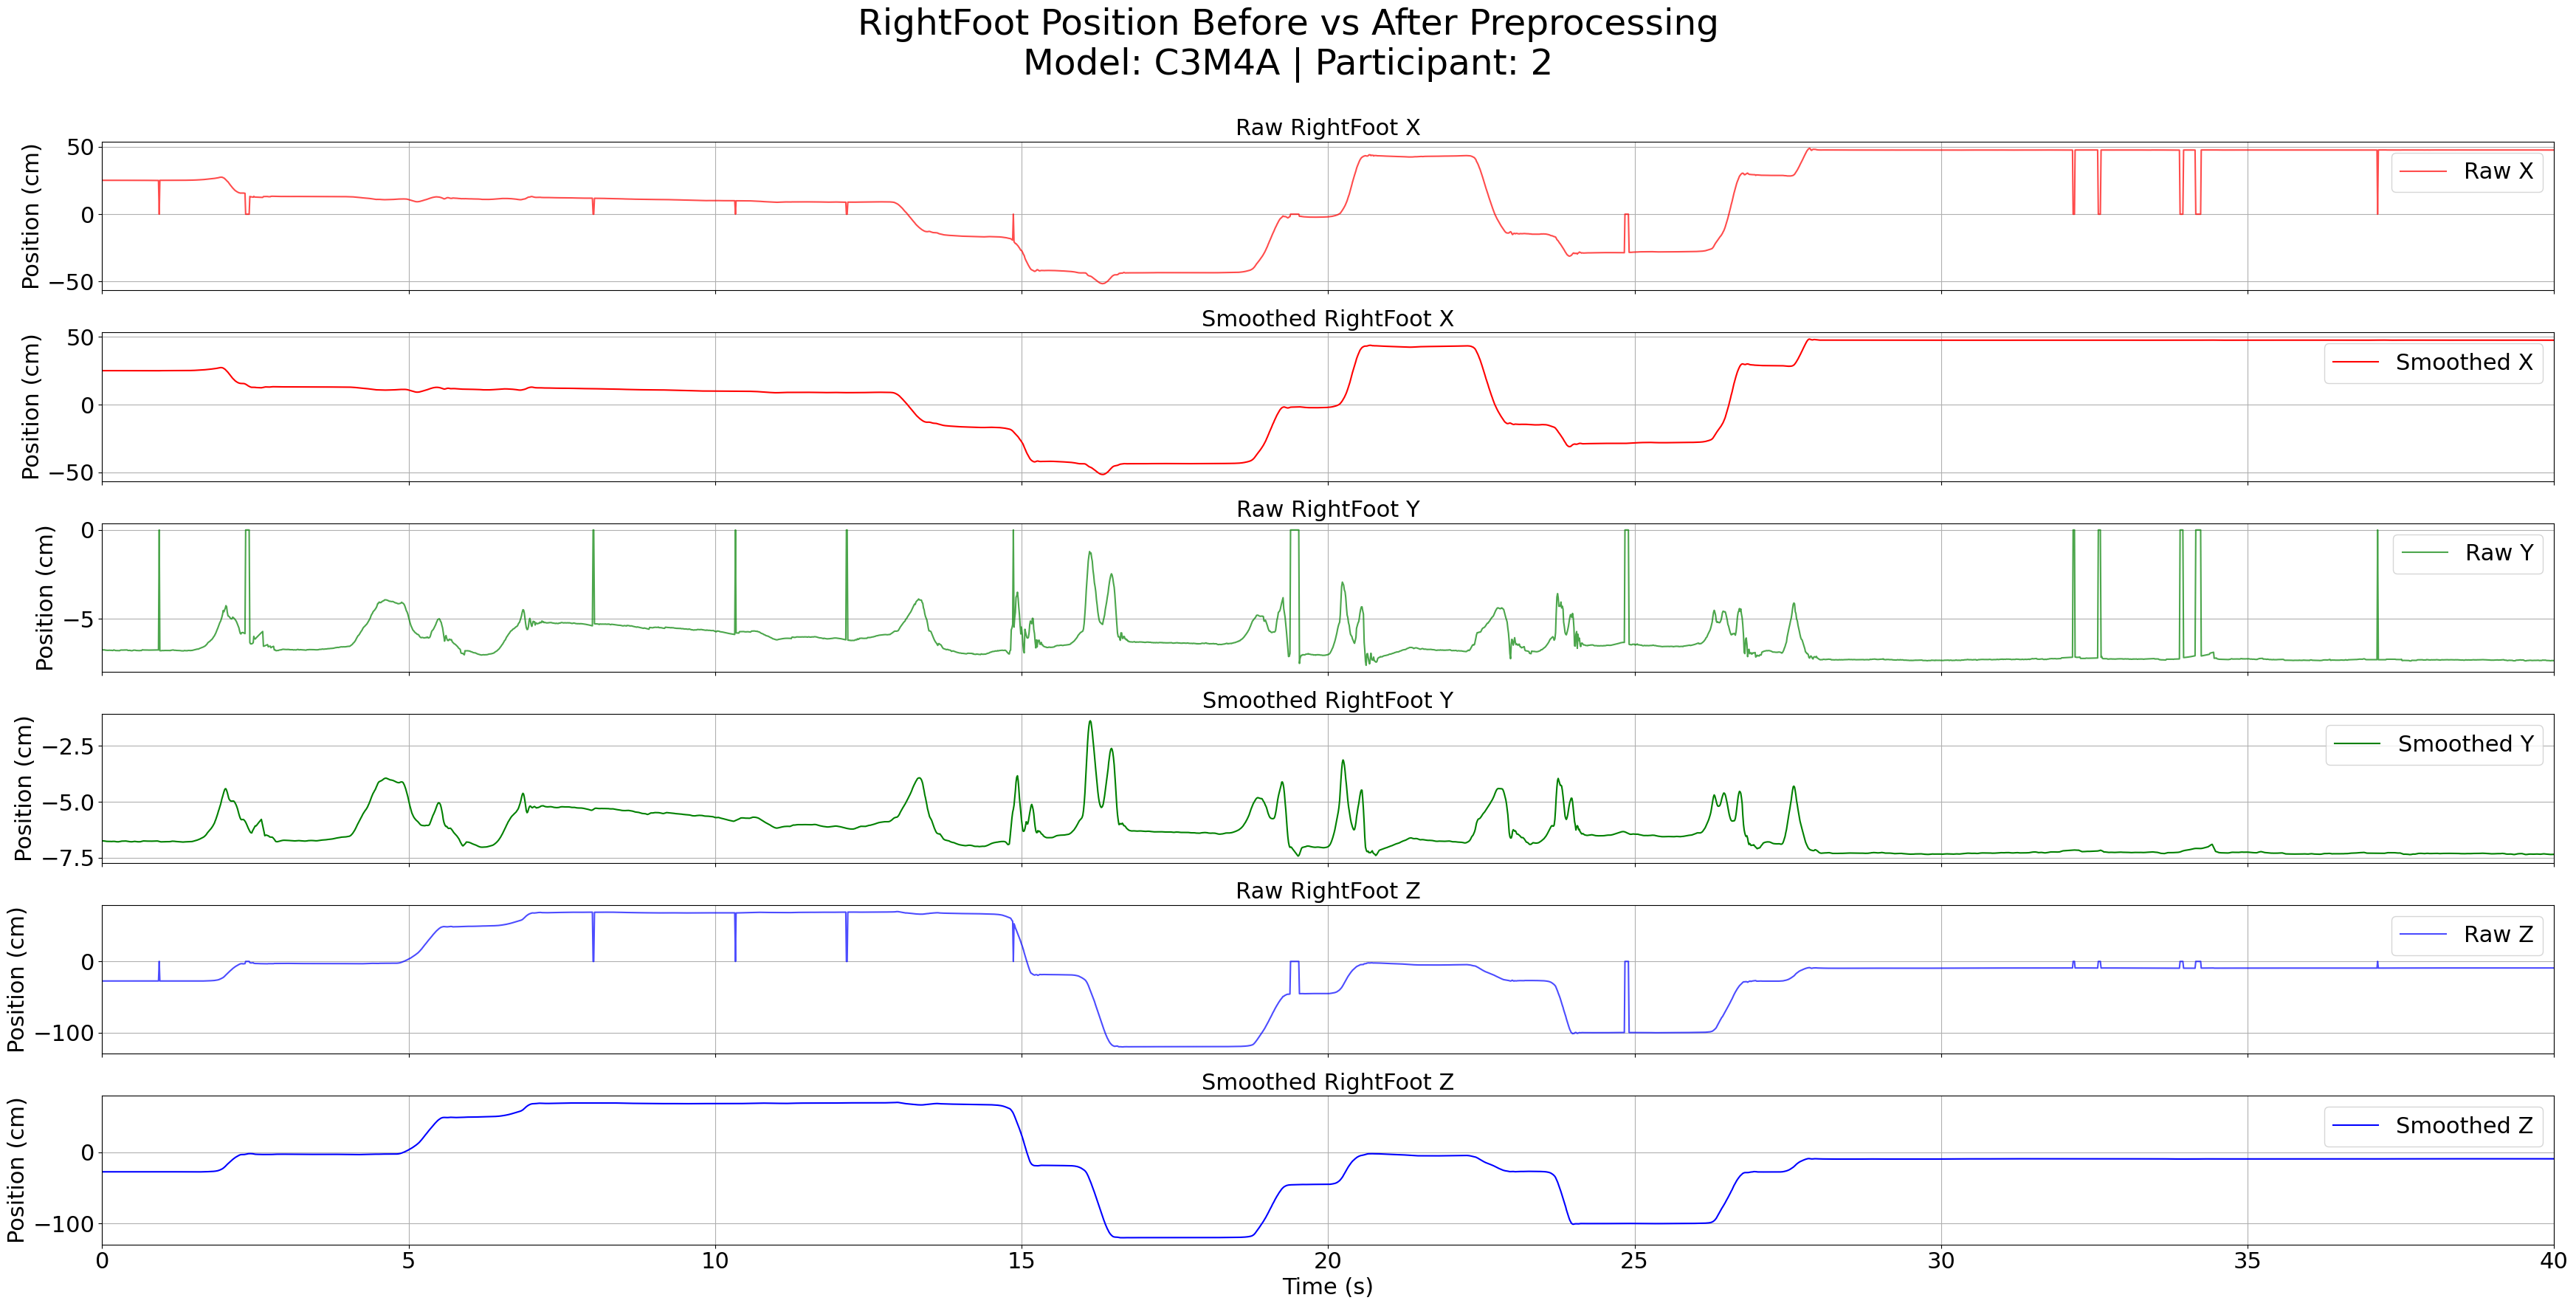

In [383]:
import matplotlib.pyplot as plt

def plot_rightfoot_before_after(df_filtered, model_name="C3M4A", participant=1,
                                x_max=50, y_limits=None):
    """
    Plot RightFoot x,y,z before and after preprocessing for a given model and participant.
    Time axis = elapsed seconds relative to model start.
    Each axis (X, Y, Z) has two stacked plots: raw and smoothed (paired vertically).
    """

    # Filter for the chosen participant and model
    df_model = df_filtered[(df_filtered["model_name"] == model_name) & 
                           (df_filtered["Participant"] == participant)].copy()

    if df_model.empty:
        print(f"⚠️ No data found for model '{model_name}' and participant {participant}.")
        return

    # Compute relative time in seconds
    start_ts = df_model['raw_timestamp'].iloc[0]
    df_model['time_s'] = (df_model['raw_timestamp'] - start_ts) / 1000

    # Keep only the first x_max seconds
    df_model = df_model[df_model['time_s'] <= x_max]

    # Make figure with 6 subplots stacked vertically
    fig, axes = plt.subplots(6, 1, figsize=(35, 18), sharex=True)
    fig.suptitle(f"RightFoot Position Before vs After Preprocessing\n"
                 f"Model: {model_name} | Participant: {participant}", fontsize=35)

    coords = ["x", "y", "z"]
    colors = ["red", "green", "blue"]

    for i, (axis, color) in enumerate(zip(coords, colors)):
        # Raw (row 2*i)
        axes[2*i].plot(df_model["time_s"], df_model[f"RightFoot_pos_{axis}"] * 100,
                       color=color, label=f"Raw {axis.upper()}", alpha=0.7)
        axes[2*i].set_ylabel("Position (cm)", fontsize=22)
        axes[2*i].set_title(f"Raw RightFoot {axis.upper()}", fontsize=22)
        axes[2*i].grid(True)
        axes[2*i].legend(fontsize=22, loc='upper right')
        axes[2*i].tick_params(axis='both', which='major', labelsize=22)

        # Smoothed (row 2*i+1)
        axes[2*i+1].plot(df_model["time_s"], df_model[f"RightFoot_pos_{axis}_smooth"] * 100,
                         color=color, label=f"Smoothed {axis.upper()}")
        axes[2*i+1].set_ylabel("Position (cm)", fontsize=22)
        axes[2*i+1].set_title(f"Smoothed RightFoot {axis.upper()}", fontsize=22)
        axes[2*i+1].grid(True)
        axes[2*i+1].legend(fontsize=22, loc='upper right')
        axes[2*i+1].tick_params(axis='both', which='major', labelsize=22)

    # Shared X-axis label
    axes[-1].set_xlabel("Time (s)", fontsize=22)

    # Limit x-axis to x_max
    for ax in axes:
        ax.set_xlim(0, x_max)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# Usage
plot_rightfoot_before_after(df_filtered, model_name="C3M4A", participant=2,
                            x_max=40)


# **Initial Pose Calibration**

Extracting the mean, std, min and max from the Initial Pose positions
Extracted for LeftFoot, Rightfoot, LefHand, RigtHand, Waist, Head

### **Extracting all Initial Poses for each participant**

In [368]:
import pandas as pd
import time

# --- Define position columns to extract ---
position_cols = [
    "LeftFoot_pos_x_smooth","LeftFoot_pos_y_smooth","LeftFoot_pos_z_smooth",
    "RightFoot_pos_x_smooth","RightFoot_pos_y_smooth","RightFoot_pos_z_smooth",
    "LeftHand_pos_x_smooth","LeftHand_pos_y_smooth","LeftHand_pos_z_smooth",
    "RightHand_pos_x_smooth","RightHand_pos_y_smooth","RightHand_pos_z_smooth",
    "Waist_pos_x_smooth","Waist_pos_y_smooth","Waist_pos_z_smooth",
    "hmd_pos_x_smooth","hmd_pos_y_smooth","hmd_pos_z_smooth",
    "raw_timestamp"
]

# --- Handle model_name if duplicated ---
if 'model_name_x' in df_filtered.columns:
    df_filtered['model_name'] = df_filtered['model_name_x']

# --- Store results ---
initial_poses = []

# --- Loop through each participant ---
for pid, df_part in df_filtered.groupby('Participant'):
    df_part = df_part.sort_index()  # Ensure chronological order

    # Detect transitions from None → model_name
    prev_model = df_part['model_name'].shift(1)
    model_transitions = df_part[(df_part['model_name'].notna()) & (prev_model.isna())]

    for idx in model_transitions.index:
        model = df_part.loc[idx, 'model_name']

        # --- NEW LOGIC: search backwards for both hands grabbing Validation_button ---
        df_before = df_part.loc[:idx - 1]  # all rows before model transition

        # Find rows where BOTH hands grabbed the validation button
        valid_rows = df_before[
            (df_before['RightHand_grabbed_name'] == "ValidationButtonRight") &
            (df_before['LeftHand_grabbed_name'] == "ValidationButtonLeft")
        ]

        if valid_rows.empty:
            # No valid initial pose found before this model transition
            continue

        # Take the LAST such row (closest to the transition)
        pose_idx = valid_rows.index[-1]
        init_pose = df_part.loc[pose_idx]

        # Convert timestamp
        ts = int(init_pose['raw_timestamp'])
        readable_time = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(ts / 1000))
        ms = int(ts % 1000)
        readable_time = f"{readable_time}.{ms:03d}"

        # Collect data
        pose_data = {
            "participant": pid,
            "model": model,
            "timestamp": ts,
            "readable_time": readable_time
        }

        for col in position_cols:
            if col in df_part.columns:
                pose_data[col] = init_pose[col]

        initial_poses.append(pose_data)
        #print(f"Participant {pid}: Found initial pose for {model} at index {pose_idx} ({readable_time})")

# --- Convert to DataFrame ---
initial_df1 = pd.DataFrame(initial_poses)

# --- Compute statistics per participant ---
grouped_stats = []

for pid, group in initial_df1.groupby('participant'):
    stats = {"participant": pid}
    
    for body_part in ["LeftFoot", "RightFoot", "LeftHand", "RightHand", "Waist", "hmd"]:
        for axis in ["x", "y", "z"]:
            col = f"{body_part}_pos_{axis}_smooth"
            stats[f"{body_part}_mean_{axis}_smooth"] = group[col].mean()
            stats[f"{body_part}_std_{axis}_smooth"] = group[col].std()
            stats[f"{body_part}_min_{axis}_smooth"] = group[col].min()
            stats[f"{body_part}_max_{axis}_smooth"] = group[col].max()
    
    grouped_stats.append(stats)

# --- Convert to DataFrame ---
stats_df = pd.DataFrame(grouped_stats)

grouped_stats = []

for pid, group in initial_df1.groupby('participant'):
    stats = {"participant": pid}

    # Count of initial poses
    stats["initial_pose_count"] = len(group)

    # Overall mean across all position columns
    pos_cols = [col for col in group.columns if "_pos_" in col]
    stats["overall_mean_position"] = group[pos_cols].mean().mean()

    # Mean and std for hands and feet only
    for part in ["LeftFoot", "RightFoot", "LeftHand", "RightHand", "Waist", "hmd"]:
        for axis in ["x", "y", "z"]:
            col = f"{part}_pos_{axis}_smooth"
            stats[f"{part}_mean_{axis}_smooth"] = group[col].mean()
            stats[f"{part}_std_{axis}_smooth"] = group[col].std()

    grouped_stats.append(stats)

# Convert to DataFrame
stats_df = pd.DataFrame(grouped_stats)

stats_df.to_excel("/Users/lisa/Desktop/8. Semester/Data/initial_pose_stats.xlsx", index=False)


# Print readable summary
for _, row in stats_df.iterrows():
    print(f"\n📌 Participant {row['participant']}")
    print(f"  - Initial pose count: {row['initial_pose_count']}")
    print(f"  - Overall mean position: {row['overall_mean_position']:.2f}")
    print("  - Hand and Foot Position Stats:")
    for part in ["LeftFoot", "RightFoot", "LeftHand", "RightHand", "Waist", "hmd"]:
        print(f"    {part}:")
        for axis in ["x", "y", "z"]:
            mean_val = row[f"{part}_mean_{axis}_smooth"]
            std_val = row[f"{part}_std_{axis}_smooth"]
            print(f"      {axis.upper()} → Mean: {mean_val:.2f}, Std: {std_val:.2f}")




📌 Participant 1.0
  - Initial pose count: 22.0
  - Overall mean position: 0.44
  - Hand and Foot Position Stats:
    LeftFoot:
      X → Mean: 0.26, Std: 0.01
      Y → Mean: 0.09, Std: 0.01
      Z → Mean: 0.25, Std: 0.02
    RightFoot:
      X → Mean: 0.27, Std: 0.01
      Y → Mean: 0.10, Std: 0.01
      Z → Mean: -0.22, Std: 0.02
    LeftHand:
      X → Mean: 0.74, Std: 0.01
      Y → Mean: 1.05, Std: 0.01
      Z → Mean: 0.16, Std: 0.01
    RightHand:
      X → Mean: 0.75, Std: 0.01
      Y → Mean: 1.04, Std: 0.01
      Z → Mean: -0.17, Std: 0.01
    Waist:
      X → Mean: 0.41, Std: 0.01
      Y → Mean: 1.04, Std: 0.01
      Z → Mean: 0.02, Std: 0.01
    hmd:
      X → Mean: 0.38, Std: 0.02
      Y → Mean: 1.71, Std: 0.01
      Z → Mean: 0.01, Std: 0.01

📌 Participant 2.0
  - Initial pose count: 22.0
  - Overall mean position: 0.39
  - Hand and Foot Position Stats:
    LeftFoot:
      X → Mean: 0.26, Std: 0.02
      Y → Mean: -0.07, Std: 0.00
      Z → Mean: 0.28, Std: 0.02
    R

### **Inital Pose mean and Standard deviation across participants**

In [369]:
import pandas as pd

body_parts = ['LeftFoot', 'RightFoot', 'LeftHand', 'RightHand', 'Waist', 'hmd']
axes = ['x', 'y', 'z']

summary_data = []

for part in body_parts:
    for axis in axes:
        mean_col = f"{part}_mean_{axis}_smooth"
        std_col = f"{part}_std_{axis}_smooth"
        overall_mean = stats_df[mean_col].mean()
        overall_std = stats_df[mean_col].std()  
        summary_data.append({
            "Body Part": part,
            "Axis": axis.upper(),
            "Mean Position": round(overall_mean, 3),
            "Standard Deviation": round(overall_std, 3)
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df)


    Body Part Axis  Mean Position  Standard Deviation
0    LeftFoot    X          0.274               0.024
1    LeftFoot    Y          0.034               0.108
2    LeftFoot    Z          0.238               0.027
3   RightFoot    X          0.278               0.020
4   RightFoot    Y          0.038               0.107
5   RightFoot    Z         -0.222               0.020
6    LeftHand    X          0.738               0.024
7    LeftHand    Y          1.033               0.024
8    LeftHand    Z          0.173               0.023
9   RightHand    X          0.746               0.022
10  RightHand    Y          1.028               0.022
11  RightHand    Z         -0.163               0.024
12      Waist    X          0.386               0.041
13      Waist    Y          0.961               0.175
14      Waist    Z          0.020               0.016
15        hmd    X          0.331               0.051
16        hmd    Y          1.561               0.173
17        hmd    Z          

### **Creating a stickfigure with the Mean of the Inital Pose data per participant**

/var/folders/s2/gpycqr3x4j13rm4l6_3d57480000gn/T/ipykernel_59481/3554006885.py:79: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


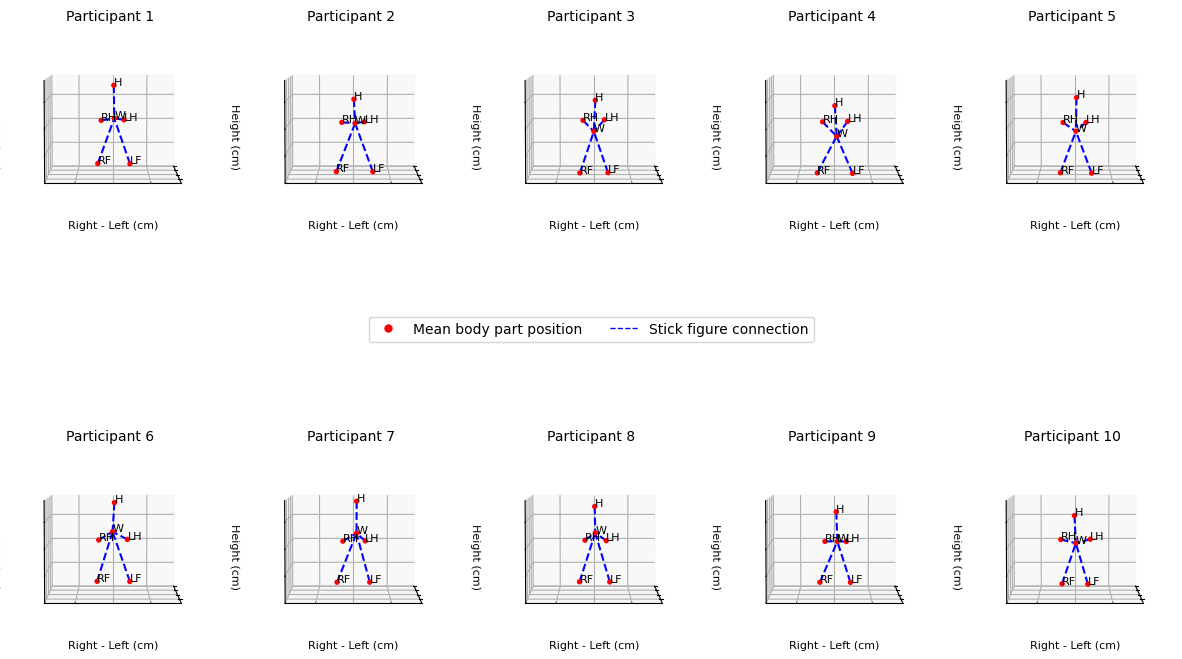

In [370]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# --- Define body part mappings ---
body_parts_map = {
    "LF": "LeftFoot",
    "RF": "RightFoot",
    "LH": "LeftHand",
    "RH": "RightHand",
    "W": "Waist",
    "H": "hmd"
}

connections = [
    ("LF", "W"),
    ("RF", "W"),
    ("LH", "W"),
    ("RH", "W"),
    ("H", "W")
]

# --- Plot each participant's mean pose ---
fig = plt.figure(figsize=(15, 10))
participants = stats_df['participant'].unique()

for idx, pid in enumerate(participants, start=1):
    ax = fig.add_subplot(2, 5, idx, projection="3d")

    # Extract mean positions for this participant
    row = stats_df[stats_df['participant'] == pid].iloc[0]

    df_pose = pd.DataFrame({
        part: {
            "X": row[f"{full}_mean_x_smooth"] * 100,
            "Y": row[f"{full}_mean_z_smooth"] * 100,
            "Z": row[f"{full}_mean_y_smooth"] * 100
        }
        for part, full in body_parts_map.items()
    }).T

    # Plot body parts
    ax.scatter(df_pose["X"], df_pose["Y"], df_pose["Z"], s=8, alpha=1, c="red")

    # Labels
    for part, row_ in df_pose.iterrows():
        ax.text(row_["X"], row_["Y"], row_["Z"], part, fontsize=8)

    # Stick figure connections
    for a, b in connections:
        ax.plot(
            [df_pose.loc[a, "X"], df_pose.loc[b, "X"]],
            [df_pose.loc[a, "Y"], df_pose.loc[b, "Y"]],
            [df_pose.loc[a, "Z"], df_pose.loc[b, "Z"]],
            c="blue", linestyle="--"
        )

    # Formatting
    ax.set_xlim(0, 190)
    ax.set_ylim(-90, 90)
    ax.set_zlim(0, 190)
    ax.set_title(f"Participant {pid}", fontsize=10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_ylabel("Right - Left (cm)", fontsize=8)
    ax.set_zlabel("Height (cm)", fontsize=8)
    ax.view_init(elev=5, azim=0)

# --- Legend ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Mean body part position',
           markerfacecolor='red', markersize=7, alpha=1),
    Line2D([0], [0], color='blue', lw=1, linestyle='--', label='Stick figure connection')
]
fig.legend(handles=legend_elements, loc='center', fontsize=10, ncol=2)

plt.tight_layout()
plt.show()


/var/folders/s2/gpycqr3x4j13rm4l6_3d57480000gn/T/ipykernel_59481/3889881809.py:122: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


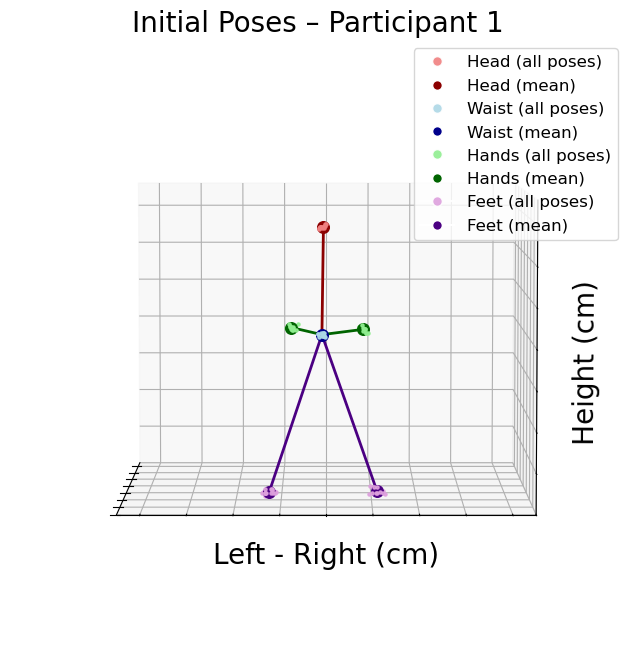

In [380]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# --- Select participant ---
participant_id = 1

df_p = initial_df1[initial_df1["participant"] == participant_id]
df_mean = stats_df[stats_df["participant"] == participant_id].iloc[0]

# --- Body part mapping ---
body_parts_map = {
    "LF": "LeftFoot",
    "RF": "RightFoot",
    "LH": "LeftHand",
    "RH": "RightHand",
    "W": "Waist",
    "H": "hmd"
}

color_map_light = {
    "LF": "plum",
    "RF": "plum",
    "LH": "lightgreen",
    "RH": "lightgreen",
    "W": "lightblue",
    "H": "lightcoral"
}

color_map_dark = {
    "LF": "indigo",
    "RF": "indigo",
    "LH": "darkgreen",
    "RH": "darkgreen",
    "W": "darkblue",
    "H": "darkred"
}

connections = [
    ("LF", "W"),
    ("RF", "W"),
    ("LH", "W"),
    ("RH", "W"),
    ("H", "W")
]

# --- Prepare figure ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# ============================================================
# 1) Plot ALL initial poses for this participant
# ============================================================
for _, row in df_p.iterrows():
    for short, full in body_parts_map.items():
        x = row[f"{full}_pos_x_smooth"] * 100
        y = row[f"{full}_pos_z_smooth"] * 100
        z = row[f"{full}_pos_y_smooth"] * 100
        ax.scatter(x, y, z, c=color_map_light[short], s=5, alpha=0.9)

# ============================================================
# 2) Plot MEAN pose for this participant
# ============================================================
mean_pose = {}
for short, full in body_parts_map.items():
    mean_pose[short] = {
        "X": df_mean[f"{full}_mean_x_smooth"] * 100,
        "Y": df_mean[f"{full}_mean_z_smooth"] * 100,
        "Z": df_mean[f"{full}_mean_y_smooth"] * 100
    }

# Plot mean dots
for short, coords in mean_pose.items():
    ax.scatter(coords["X"], coords["Y"], coords["Z"],
               c=color_map_dark[short], s=70)

# ============================================================
# 3) Stick figure connections (mean pose only)
# ============================================================
for a, b in connections:
    ax.plot(
        [mean_pose[a]["X"], mean_pose[b]["X"]],
        [mean_pose[a]["Y"], mean_pose[b]["Y"]],
        [mean_pose[a]["Z"], mean_pose[b]["Z"]],
        c=color_map_dark[a], linewidth=2
    )

# --- Formatting ---
ax.set_xlim(0, 190)
ax.set_ylim(-90, 90)
ax.set_zlim(0, 190)
ax.set_title(f"Initial Poses – Participant {participant_id}", fontsize=20)
ax.set_ylabel("Left - Right (cm)", fontsize=20)
ax.set_zlabel("Height (cm)", fontsize=20)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.tick_params(axis='both', which='major', labelsize=15)
ax.view_init(elev=5, azim=180)

# --- Legend ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Head (all poses)',
           markerfacecolor='lightcoral', markersize=7, alpha=0.9),
    Line2D([0], [0], marker='o', color='w', label='Head (mean)',
           markerfacecolor='darkred', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Waist (all poses)',
           markerfacecolor='lightblue', markersize=7, alpha=0.9),
    Line2D([0], [0], marker='o', color='w', label='Waist (mean)',
           markerfacecolor='darkblue', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Hands (all poses)',
           markerfacecolor='lightgreen', markersize=7, alpha=0.9),
    Line2D([0], [0], marker='o', color='w', label='Hands (mean)',
           markerfacecolor='darkgreen', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Feet (all poses)',
           markerfacecolor='plum', markersize=7, alpha=0.9),
    Line2D([0], [0], marker='o', color='w', label='Feet (mean)',
           markerfacecolor='indigo', markersize=7),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

### **Plotting a stickfigure representing the mean position across all participants**

- light red represents the mean of each participant 
- dark red represents the mean across all participants

/var/folders/s2/gpycqr3x4j13rm4l6_3d57480000gn/T/ipykernel_59481/2589575097.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


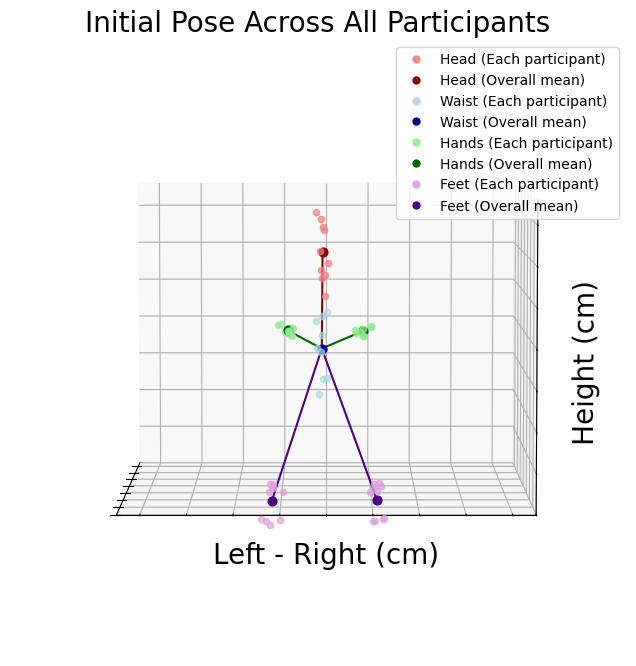

In [373]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# --- Define body part mappings and color groups ---
body_parts_map = {
    "LF": "LeftFoot",
    "RF": "RightFoot",
    "LH": "LeftHand",
    "RH": "RightHand",
    "W": "Waist",
    "H": "hmd"
}

color_map_light = {
    "LF": "plum",
    "RF": "plum",
    "LH": "lightgreen",
    "RH": "lightgreen",
    "W": "lightblue",
    "H": "lightcoral"
}

color_map_dark = {
    "LF": "indigo",
    "RF": "indigo",
    "LH": "darkgreen",
    "RH": "darkgreen",
    "W": "darkblue",
    "H": "darkred"
}

connections = [
    ("LF", "W"),
    ("RF", "W"),
    ("LH", "W"),
    ("RH", "W"),
    ("H", "W")
]

# --- Prepare figure ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# --- Plot each participant's mean pose as light-colored dots ---
for _, row in stats_df.iterrows():
    for short, full in body_parts_map.items():
        x = row[f"{full}_mean_x_smooth"] * 100
        y = row[f"{full}_mean_z_smooth"] * 100
        z = row[f"{full}_mean_y_smooth"] * 100
        ax.scatter(x, y, z, c=color_map_light[short], s=20, alpha=0.7)

# --- Compute overall mean pose ---
mean_pose = {
    part: {
        "X": stats_df[f"{full}_mean_x_smooth"].mean() * 100,
        "Y": stats_df[f"{full}_mean_z_smooth"].mean() * 100,
        "Z": stats_df[f"{full}_mean_y_smooth"].mean() * 100
    }
    for part, full in body_parts_map.items()
}

df_pose = pd.DataFrame(mean_pose).T

# --- Plot overall mean pose as dark-colored dots ---
for part, row in df_pose.iterrows():
    ax.scatter(row["X"], row["Y"], row["Z"], s=40, alpha=1, c=color_map_dark[part])
    #ax.text(row["X"], row["Y"], row["Z"], part, fontsize=20)

# --- Stick figure connections for overall mean pose ---
for a, b in connections:
    ax.plot(
        [df_pose.loc[a, "X"], df_pose.loc[b, "X"]],
        [df_pose.loc[a, "Y"], df_pose.loc[b, "Y"]],
        [df_pose.loc[a, "Z"], df_pose.loc[b, "Z"]],
        c=color_map_dark[a], linestyle="-", linewidth=1.5
    )

# --- Formatting ---
ax.set_xlim(0, 190)
ax.set_ylim(-90, 90)
ax.set_zlim(0, 190)
ax.set_title("Initial Pose Across All Participants", fontsize=20)
ax.set_ylabel("Left - Right (cm)", fontsize=20)
ax.set_zlabel("Height (cm)", fontsize=20)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.tick_params(axis='both', which='major', labelsize=15)
ax.view_init(elev=5, azim=180)

# --- Legend ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Head (Each participant)',
           markerfacecolor='lightcoral', markersize=7, alpha=0.9),
    Line2D([0], [0], marker='o', color='w', label='Head (Overall mean)',
           markerfacecolor='darkred', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Waist (Each participant)',
           markerfacecolor='lightblue', markersize=7, alpha=0.9),
    Line2D([0], [0], marker='o', color='w', label='Waist (Overall mean)',
           markerfacecolor='darkblue', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Hands (Each participant)',
           markerfacecolor='lightgreen', markersize=7, alpha=0.9),
    Line2D([0], [0], marker='o', color='w', label='Hands (Overall mean)',
           markerfacecolor='darkgreen', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Feet (Each participant)',
           markerfacecolor='plum', markersize=7, alpha=0.9),
    Line2D([0], [0], marker='o', color='w', label='Feet (Overall mean)',
           markerfacecolor='indigo', markersize=7),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()


### **Data frame with the Initial Positions across all participants**

In [408]:
import pandas as pd

body_parts = ["LeftFoot", "RightFoot", "LeftHand", "RightHand", "Waist", "hmd"]
axes = ["x", "y", "z"]

summary_stats = []

for bp in body_parts:
    stats = {"BodyPart": bp}
    for axis in axes:
        col = f"{bp}_pos_{axis}_smooth"
        stats[f"mean_{axis}"] = initial_df1[col].mean() * 100   # convert to cm
        stats[f"std_{axis}"] = initial_df1[col].std() * 100
    summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)

print("\n Mean and Standard Deviation for All Body Parts (cm):\n")
print(summary_df.round(2))



 Mean and Standard Deviation for All Body Parts (cm):

    BodyPart  mean_x  std_x  mean_y  std_y  mean_z  std_z
0   LeftFoot   27.43   3.01    3.18  10.32   23.80   3.55
1  RightFoot   27.85   2.64    3.60  10.17  -22.18   2.71
2   LeftHand   73.71   2.94  103.24   2.62   17.27   2.73
3  RightHand   74.51   2.67  102.80   2.43  -16.28   2.77
4      Waist   38.53   4.69   95.72  16.56    2.00   2.57
5        hmd   33.05   5.31  155.73  16.35    1.62   1.82


### **Initial Pose Box Plots for 10 Participants**

/var/folders/s2/gpycqr3x4j13rm4l6_3d57480000gn/T/ipykernel_59481/3524615481.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/s2/gpycqr3x4j13rm4l6_3d57480000gn/T/ipykernel_59481/3524615481.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/s2/gpycqr3x4j13rm4l6_3d57480000gn/T/ipykernel_59481/3524615481.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


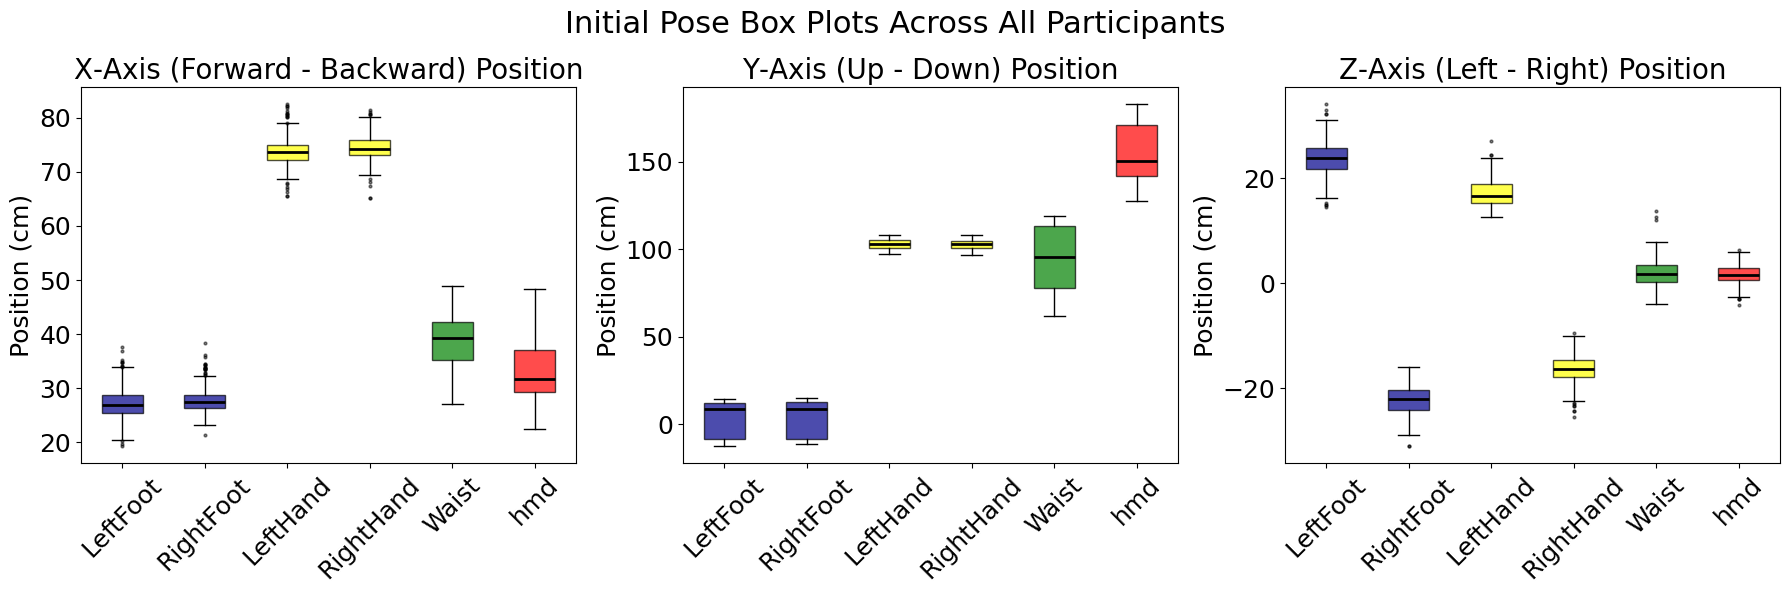

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Body parts and colors ---
body_parts = ["LeftFoot", "RightFoot", "LeftHand", "RightHand", "Waist", "hmd"]

color_map = {
    "LeftFoot": "darkblue",
    "RightFoot": "darkblue",
    "LeftHand": "yellow",
    "RightHand": "yellow",
    "Waist": "green",
    "hmd": "red"
}

# --- Extract X, Y, Z data (converted to cm) ---
data_x = [initial_df1[f"{bp}_pos_x_smooth"] * 100 for bp in body_parts]
data_y = [initial_df1[f"{bp}_pos_y_smooth"] * 100 for bp in body_parts]
data_z = [initial_df1[f"{bp}_pos_z_smooth"] * 100 for bp in body_parts]

# --- Create figure ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ["X‑Axis (Forward - Backward) Position", "Y‑Axis (Up - Down) Position", "Z‑Axis (Left - Right) Position"]
datasets = [data_x, data_y, data_z]
ylabels = ["Position (cm)", "Position (cm)", "Position (cm)"]




# --- Plot each axis ---
for ax, data, title, ylabel in zip(axes, datasets, titles, ylabels):

    flierprops = dict(marker='o', markersize=2, markerfacecolor='black', alpha=0.5)
    medianprops = dict(color='black', linewidth=2)


    bp = ax.boxplot(
        data,
        labels=body_parts,
        patch_artist=True, 
        flierprops=flierprops,
        medianprops=medianprops
    )

    # Apply color coding
    for patch, bp_name in zip(bp["boxes"], body_parts):
        patch.set_facecolor(color_map[bp_name])
        patch.set_alpha(0.7)

    ax.set_title(title, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='both', labelsize=18)


# --- Final formatting ---
fig.suptitle("Initial Pose Box Plots Across All Participants", fontsize=22)
plt.tight_layout()
plt.show()



# **Movement Analysis**

## **Remove Participants building phases**

In [324]:
# Define the conditions you want to remove
remove_conditions = (
    ((df_all['Participant'] == 6) & df_all['model_name'].isin(["C3M5F", "C3M2A","C3M3F"])) |
    ((df_all['Participant'] == 7) & (df_all['model_name'] == "C3M3F"))
)

# Keep everything that does NOT match the conditions
df_filtered = df_all[~remove_conditions].copy()

# Optional: check how many rows were removed
print(f"Removed {remove_conditions.sum()} rows")


Removed 86443 rows


## **Generating a Video of a Stickfigure Moving over time for the Model**

In [ ]:
#----------------------------------------------
# Here we generate a video of a stickfigure for one specific participant and one specific model with the position and rotation values of the devices
#-----------------------------------------------

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import os
from tqdm import tqdm  # progress bar
from scipy.spatial.transform import Rotation as R
import numpy as np


# --- Output setup ---
output_dir = "/Users/lisa/Desktop/8. Semester"
os.makedirs(output_dir, exist_ok=True)

writer = FFMpegWriter(fps=90, metadata=dict(artist='Lisa'), bitrate=1800)

# --- SELECT MODEL TO ANIMATE ---
target_model = "C3M2A"   # change this to your desired model name
target_participant = 10
segment = df_filtered[
    (df_filtered["model_name"] == target_model) &
    (df_filtered["Participant"] == target_participant)
].copy()


if segment.empty:
    raise ValueError(f"No data found for model '{target_model}'")

# --- Body parts and colors ---
body_parts_map = {
    "H": ("hmd_pos_x_smooth", "hmd_pos_y_smooth", "hmd_pos_z_smooth"),  # Head (HMD)
    "W": ("Waist_pos_x_smooth", "Waist_pos_y_smooth", "Waist_pos_z_smooth"),
    "LF": ("LeftFoot_pos_x_smooth", "LeftFoot_pos_y_smooth", "LeftFoot_pos_z_smooth"),
    "RF": ("RightFoot_pos_x_smooth", "RightFoot_pos_y_smooth", "RightFoot_pos_z_smooth"),
    "LH": ("LeftHand_pos_x_smooth", "LeftHand_pos_y_smooth", "LeftHand_pos_z_smooth"),
    "RH": ("RightHand_pos_x_smooth", "RightHand_pos_y_smooth", "RightHand_pos_z_smooth"),
}

rotation_map = {
    "H": "hmd",
    "W": "Waist",
    "LF": "LeftFoot",
    "RF": "RightFoot",
    "LH": "LeftHand",
    "RH": "RightHand",
}

# Mapping from short codes to full names for legend
full_names = {
    "H": "Head (HMD)",
    "W": "Waist",
    "LF": "Left Foot",
    "RF": "Right Foot",
    "LH": "Left Hand",
    "RH": "Right Hand"
}

body_colors = {
    "H": "blue",
    "W": "green",
    "LF": "orange",
    "RF": "red",
    "LH": "purple",
    "RH": "cyan"
}

connections = [
    ("H", "W"),
    ("W", "LF"),
    ("W", "RF"),
    ("W", "LH"),
    ("W", "RH"),
]

AXIS_LENGTH = 14  # cm
local_axes = np.eye(3) * AXIS_LENGTH  # X, Y, Z unit axes


print(f"Animating model: {target_model}, samples: {len(segment)}")

# --- Figure setup ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.set_xlabel("X (backward-forward, cm)", fontsize=14)
ax.set_ylabel("Z (right-left, cm)", fontsize=14)
ax.set_zlabel("Y (height, cm)", fontsize=14)
ax.set_title(f"Stick Figure Animation ({target_model})", fontsize=16)

# Convert VR units (m) to cm
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)
ax.set_zlim(0, 180)

# Initialize scatter points with full names for legend
scatters = {
    short: ax.scatter([], [], [], s=40, label=full_names[short], color=body_colors[short])
    for short in body_parts_map.keys()
}

# No floating text labels — legend will serve as the agenda
labels = {}

# Initialize stick lines
lines = [ax.plot([], [], [], 'k-')[0] for _ in connections]

# Orientation axes (3 per body part)
axis_lines = {}

for short in body_parts_map.keys():
    axis_lines[short] = {
        "x": ax.plot([], [], [], color="blue", linewidth=2)[0],
        "y": ax.plot([], [], [], color="green", linewidth=2)[0],
        "z": ax.plot([], [], [], color="red", linewidth=2)[0],
    }

# Add legend (agenda)
ax.legend(loc="upper left", fontsize=10, title="Body Parts", framealpha=0.8)

# --- Init function ---
def init():
    for sc in scatters.values():
        sc._offsets3d = ([], [], [])
    for ln in lines:
        ln.set_data([], [])
        ln.set_3d_properties([])
    for part_axes in axis_lines.values():
        for ln in part_axes.values():
            ln.set_data([], [])
            ln.set_3d_properties([])
    return list(scatters.values()) + \
           [ln for p in axis_lines.values() for ln in p.values()]


# --- Update function ---
def update(frame):
    coords = {}

    for short, cols in body_parts_map.items():
        x = segment[cols[0]].iloc[frame] * 100
        y = segment[cols[2]].iloc[frame] * 100
        z = segment[cols[1]].iloc[frame] * 100
        coords[short] = np.array([x, y, z])
        scatters[short]._offsets3d = ([x], [y], [z])

        # --- ROTATION VISUALIZATION ---
        prefix = rotation_map[short]
        q = segment[
            [f"{prefix}_rot_x",
             f"{prefix}_rot_y",
             f"{prefix}_rot_z",
             f"{prefix}_rot_w"]
        ].iloc[frame].values

        rot = R.from_quat(q)

    # Stick figure lines
    for (a, b), line in zip(connections, lines):
        pa, pb = coords[a], coords[b]
        line.set_data([pa[0], pb[0]], [pa[1], pb[1]])
        line.set_3d_properties([pa[2], pb[2]])

    return list(scatters.values()) + lines


# --- Animation ---
FPS = 90
interval = 1000 / FPS
ani = FuncAnimation(fig, update, frames=len(segment),
                    init_func=init, interval=interval, blit=True)

output_file = os.path.join(output_dir, f"StickFigure_{target_model}_participant_{target_participant}.mp4")

# --- Save with progress bar ---
with tqdm(total=len(segment), desc="Rendering frames", unit="frame") as pbar:
    ani.save(output_file, writer=writer,
             progress_callback=lambda i, n: pbar.update(1))

plt.close(fig)
print(f"✅ Saved stick figure animation: {output_file}")


Animating model: C3M2A, samples: 13002


Rendering frames: 100%|██████████| 13002/13002 [09:55<00:00, 21.82frame/s]

✅ Saved stick figure animation: /Users/lisa/Desktop/8. Semester/StickFigure_C3M2A_participant_10.mp4


## **Plotting the walking path of all participants for each complexity**

- First plot: all the easy complexity models
- Second plot: all the medium complexity models
- Third plot: all the hard complexity models

⚠️ No data for model 'C3M2A' and participant 6
⚠️ No data for model 'C3M5F' and participant 6
⚠️ No data for model 'C3M3F' and participant 6
⚠️ No data for model 'C3M3F' and participant 7


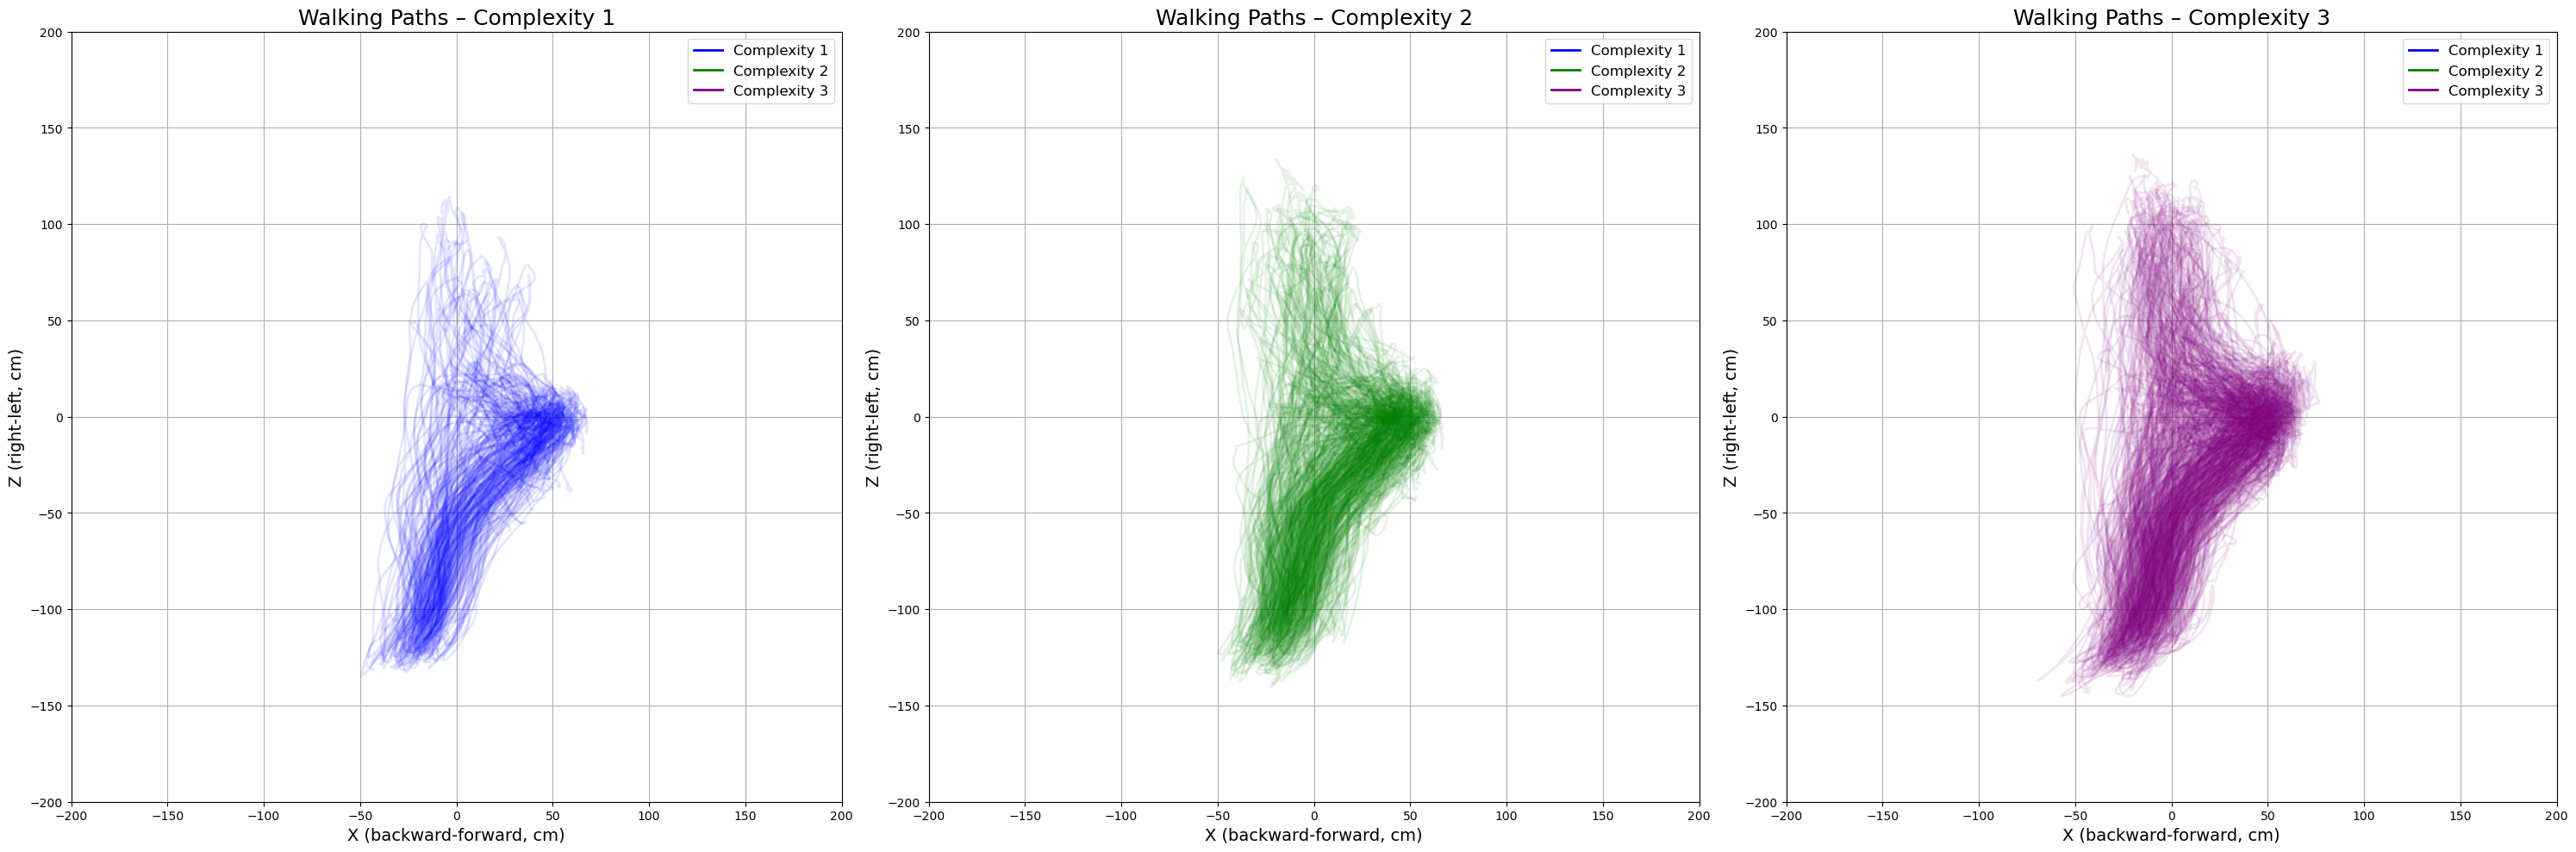

Saved overlay plot for selected participants → /Users/lisa/Desktop/8. Semester/Plots/WaistPaths_Overlay_Selected.png


In [339]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

# --- Output setup ---
output_dir = "/Users/lisa/Desktop/8. Semester/Plots"
os.makedirs(output_dir, exist_ok=True)

# --- Define model groups for each complexity ---
model_groups = [
    ["C1M6A", "C1M1F", "C1M4A", "C1M3F", "C1M5F", "C1M2A"],  # Complexity 1
    ["C2M4A", "C2M3F", "C2M1F", "C2M6A", "C2M5F", "C2M2A"],  # Complexity 2
    ["C3M4A", "C3M1F", "C3M2A", "C3M5F", "C3M3F", "C3M6A"]   # Complexity 3
]

# --- Manually select participants to include ---
selected_participants = [1,2,3,4,5,6,7,8,9,10]  # Adjust as needed

# --- Color mapping for complexities ---
complexity_colors = {0: "blue", 1: "green", 2: "purple"}

# --- Plot setup ---
fig, axes = plt.subplots(1, 3, figsize=(30, 10))

for i, model_list in enumerate(model_groups):
    ax = axes[i]
    ax.set_title(f"Walking Paths – Complexity {i+1}", fontsize=18)
    ax.set_xlabel("X (backward-forward, cm)", fontsize=14)
    ax.set_ylabel("Z (right-left, cm)", fontsize=14)
    ax.set_xlim(-200, 200)
    ax.set_ylim(-200, 200)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    for pid in selected_participants:
        init_lf_x = init_lf_z = init_rf_x = init_rf_z = init_waist_x = init_waist_z = None

        for model_name in model_list:
            segment = df_filtered[(df_filtered["model_name"] == model_name) & (df_filtered["Participant"] == pid)]
            if segment.empty:
                print(f"⚠️ No data for model '{model_name}' and participant {pid}")
                continue

            waist_x = segment["Waist_pos_x_smooth"] * 100
            waist_z = segment["Waist_pos_z_smooth"] * 100

            # Save initial waist position from first valid model
            if init_waist_x is None and not waist_x.empty:
                init_waist_x = waist_x.iloc[0]
                init_waist_z = waist_z.iloc[0]

            # --- Plot waist path with complexity color ---
            ax.plot(waist_x, waist_z, color=complexity_colors[i], linewidth=2, alpha=0.1)

    # --- Legend ---
    legend_elements = [
        Line2D([0], [0], color="blue", lw=2, label="Complexity 1"),
        Line2D([0], [0], color="green", lw=2, label="Complexity 2"),
        Line2D([0], [0], color="purple", lw=2, label="Complexity 3"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=12)

plt.tight_layout()

# Save static image
output_file = os.path.join(output_dir, "WaistPaths_Overlay_Selected.png")
plt.savefig(output_file, dpi=300)
plt.show()

print(f"Saved overlay plot for selected participants → {output_file}")


## **Plotting the walking path for all participant for each complexity and familiar or abstract model**

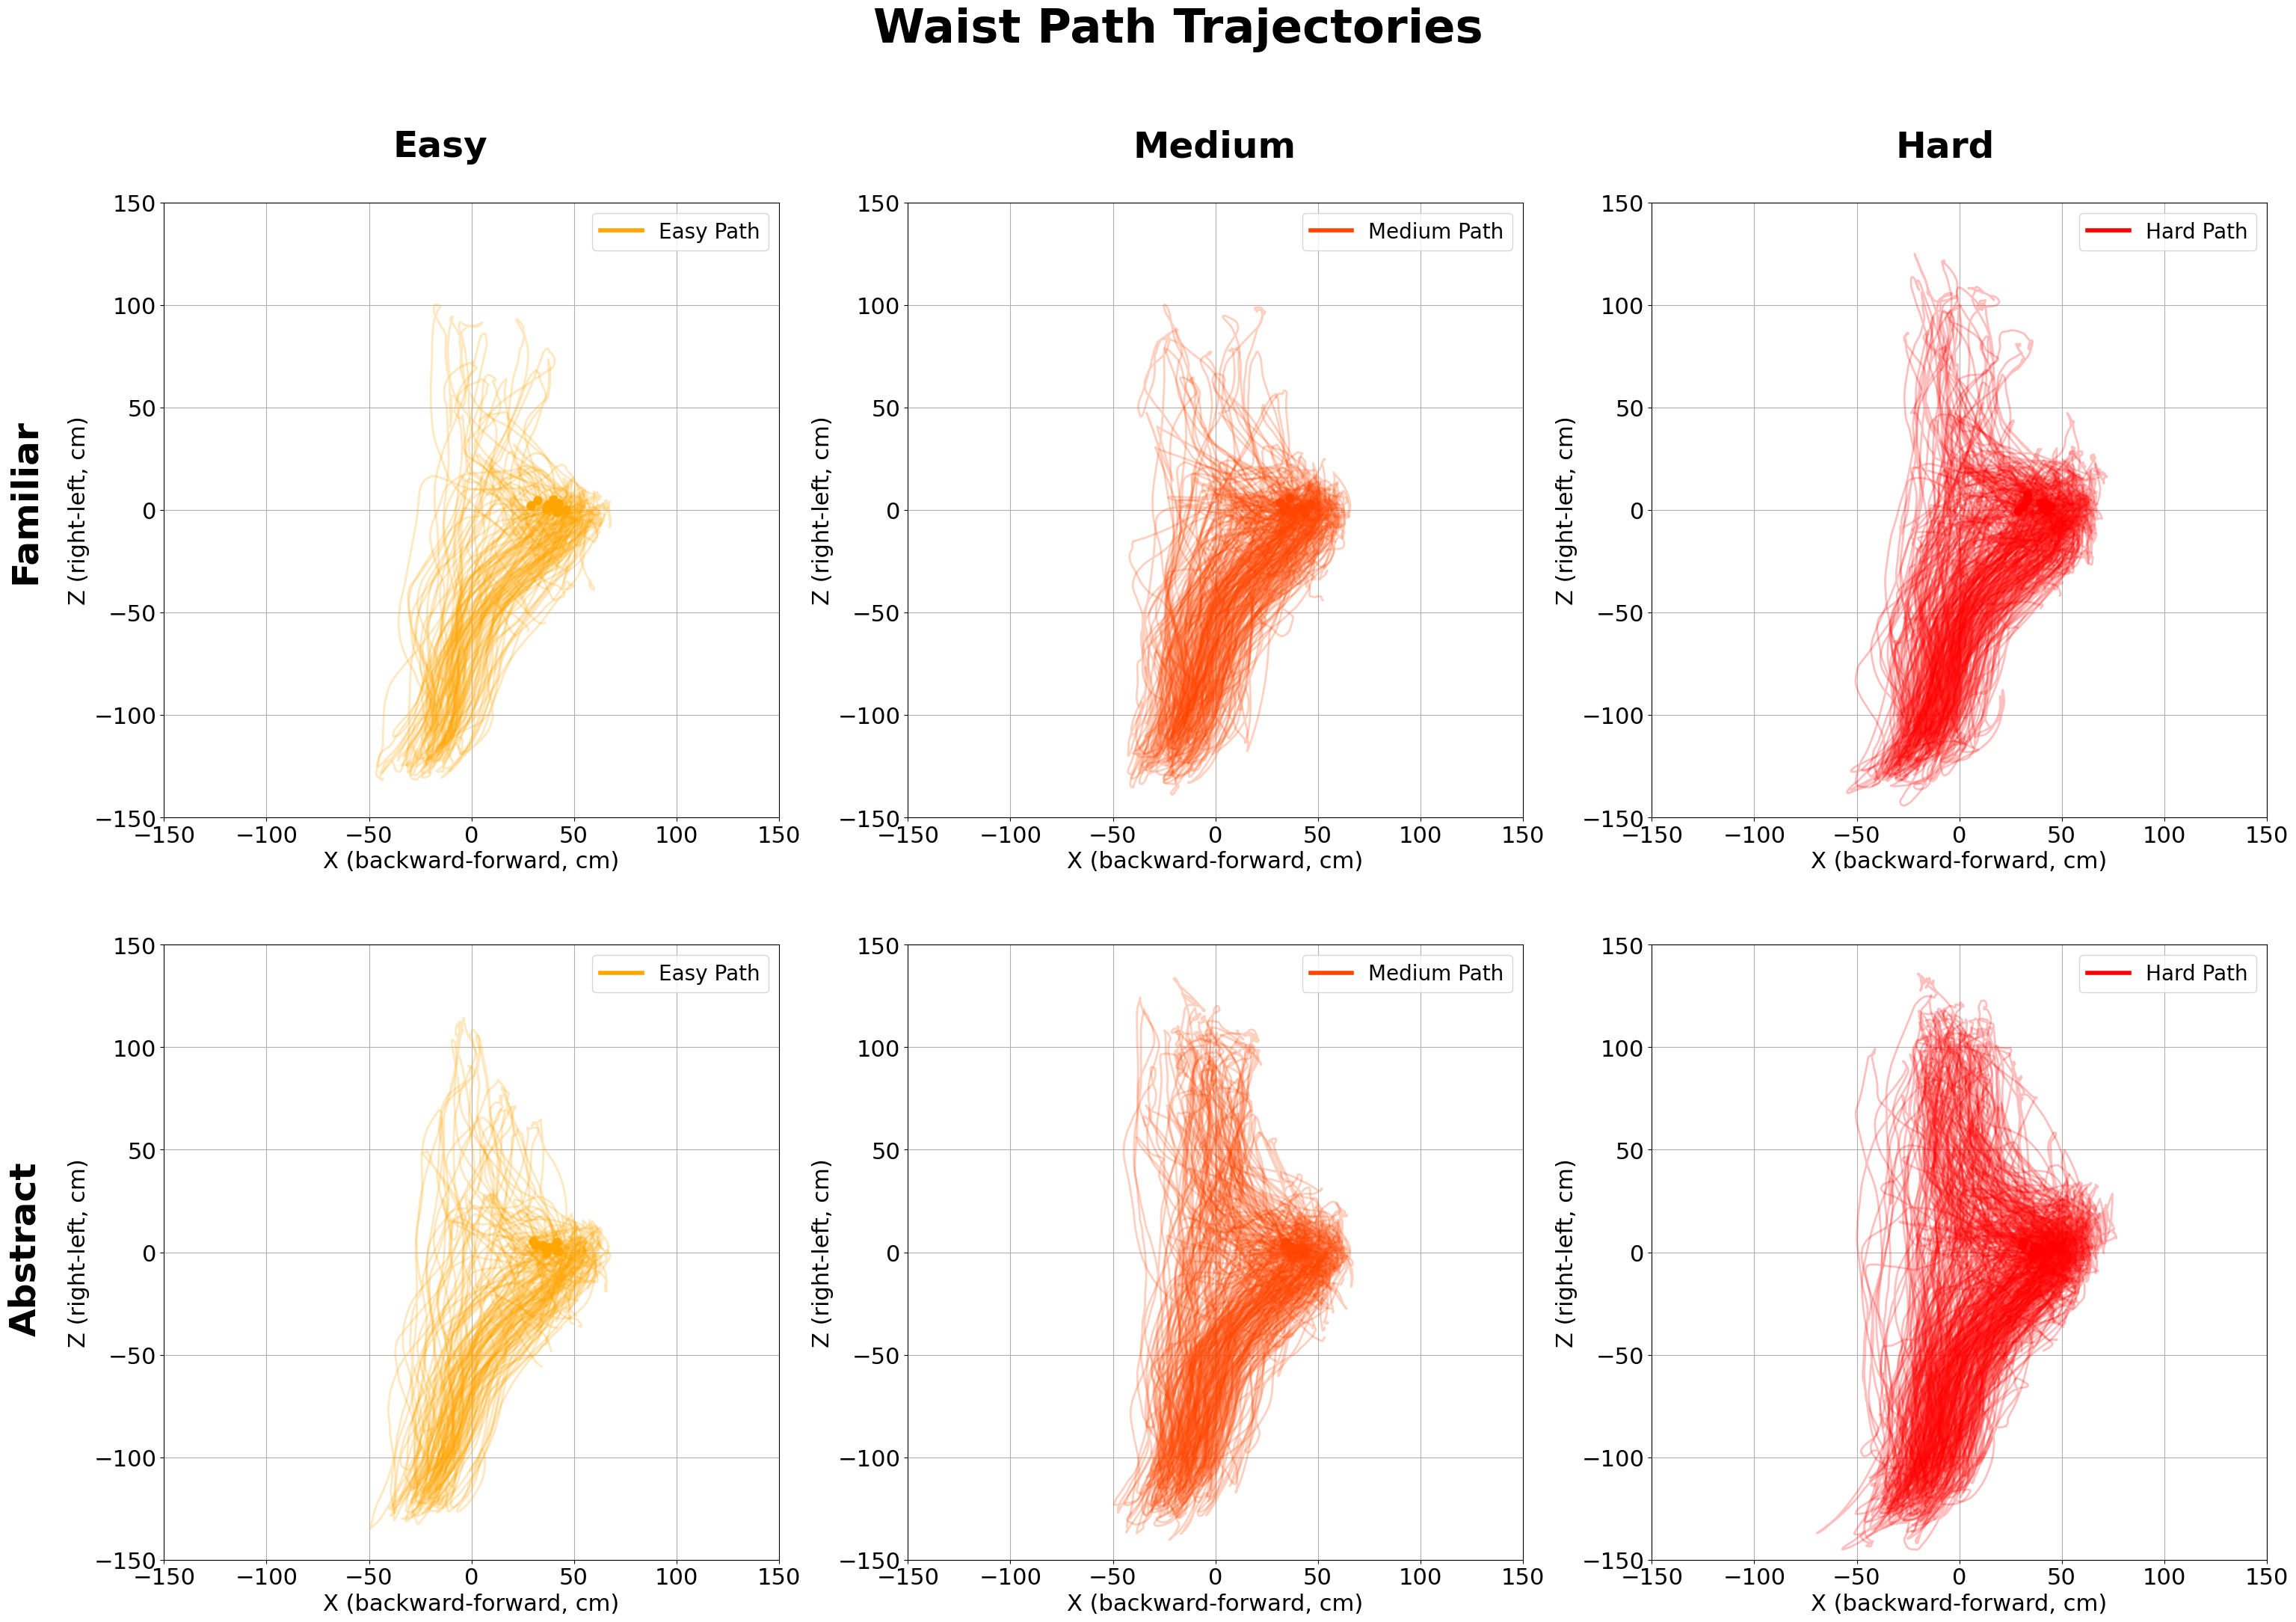

Saved 6-panel overlay plot for selected participants → /Users/lisa/Desktop/8. Semester/Plots/WaistPaths_Overlay_Complexity_Selected.png


In [422]:
import matplotlib.pyplot as plt
import os

# --- Output setup ---
output_dir = "/Users/lisa/Desktop/8. Semester/Plots"
os.makedirs(output_dir, exist_ok=True)

# --- Define model groups by complexity and familiarity ---
model_groups = [
    ["C1M1F", "C1M3F", "C1M5F"],  # Easy – Familiar
    ["C2M3F", "C2M1F", "C2M5F"],  # Medium – Familiar
    ["C3M5F", "C3M3F", "C3M1F"],  # Hard – Familiar
    ["C1M6A", "C1M4A", "C1M2A"],  # Easy – Abstract
    ["C2M2A", "C2M6A", "C2M4A"],  # Medium – Abstract
    ["C3M6A", "C3M2A", "C3M4A"]   # Hard – Abstract
]

titles = [
    "Easy & Familiar Models",
    "Medium & Familiar Models",
    "Hard & Familiar Models",
    "Easy & Abstract Models",
    "Medium & Abstract Models",
    "Hard & Abstract Models"
]

selected_participants = [1,2,3,4,5,6,7,8,9,10]

difficulty_colors = {
    "easy": "orange",
    "medium": "orangered",
    "hard": "red"
}

difficulty_map = {
    0: "easy",
    1: "medium",
    2: "hard",
    3: "easy",
    4: "medium",
    5: "hard"
}

# --- Plot setup: 2 rows, 3 columns ---
fig, axes = plt.subplots(2, 3, figsize=(30, 20))

for i, model_list in enumerate(model_groups):

    difficulty = difficulty_map[i]
    path_color = difficulty_colors[difficulty]

    ax = axes[i // 3, i % 3]
    ax.set_xlabel("X (backward-forward, cm)", fontsize=22)
    ax.set_ylabel("Z (right-left, cm)", fontsize=22)
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.set_xlim(-150, 150)
    ax.set_ylim(-150, 150)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    for pid in selected_participants:

        init_waist_x = init_waist_z = None

        for model_name in model_list:
            segment = df_filtered[(df_filtered["model_name"] == model_name) &
                                  (df_filtered["Participant"] == pid)]
            if segment.empty:
                continue

            waist_x = segment["Waist_pos_x_smooth"] * 100
            waist_z = segment["Waist_pos_z_smooth"] * 100

            if init_waist_x is None and not waist_x.empty:
                init_waist_x = waist_x.iloc[0]
                init_waist_z = waist_z.iloc[0]

            ax.plot(waist_x, waist_z, color=path_color, linewidth=2, alpha=0.25)

        if init_waist_x is not None:
            ax.plot(init_waist_x, init_waist_z, marker='o', color=path_color, markersize=8)

    legend_elements = [
        Line2D([0], [0], color=path_color, lw=4, label=f'{difficulty.capitalize()} Path')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=20)

plt.tight_layout()

fig.suptitle("Waist Path Trajectories", fontsize=45, fontweight='bold', y=1.1)

# ============================================================
# ADD COLUMN HEADERS (Easy, Medium, Hard)
# ============================================================
fig.text(0.15, 1, "Easy", fontsize=35, fontweight='bold')
fig.text(0.48, 1, "Medium", fontsize=35, fontweight='bold')
fig.text(0.82, 1, "Hard", fontsize=35, fontweight='bold')

# ============================================================
# ADD ROW HEADERS (Familiar, Abstract)
# ============================================================
fig.text(-0.022, 0.77, "Familiar", fontsize=35, fontweight='bold', rotation=90, va='center')
fig.text(-0.022, 0.27, "Abstract", fontsize=35, fontweight='bold', rotation=90, va='center')

# Save static image
output_file = os.path.join(output_dir, "WaistPaths_Overlay_Complexity_Selected.png")
plt.savefig(output_file, dpi=300)
plt.show()

print(f"Saved 6-panel overlay plot for selected participants → {output_file}")


## **Walking path of all participant across all the familiar and all the abstract models in two plots**

⚠️ No data for model 'C3M5F' and participant 6
⚠️ No data for model 'C3M3F' and participant 6
⚠️ No data for model 'C3M3F' and participant 7
⚠️ No data for model 'C3M2A' and participant 6


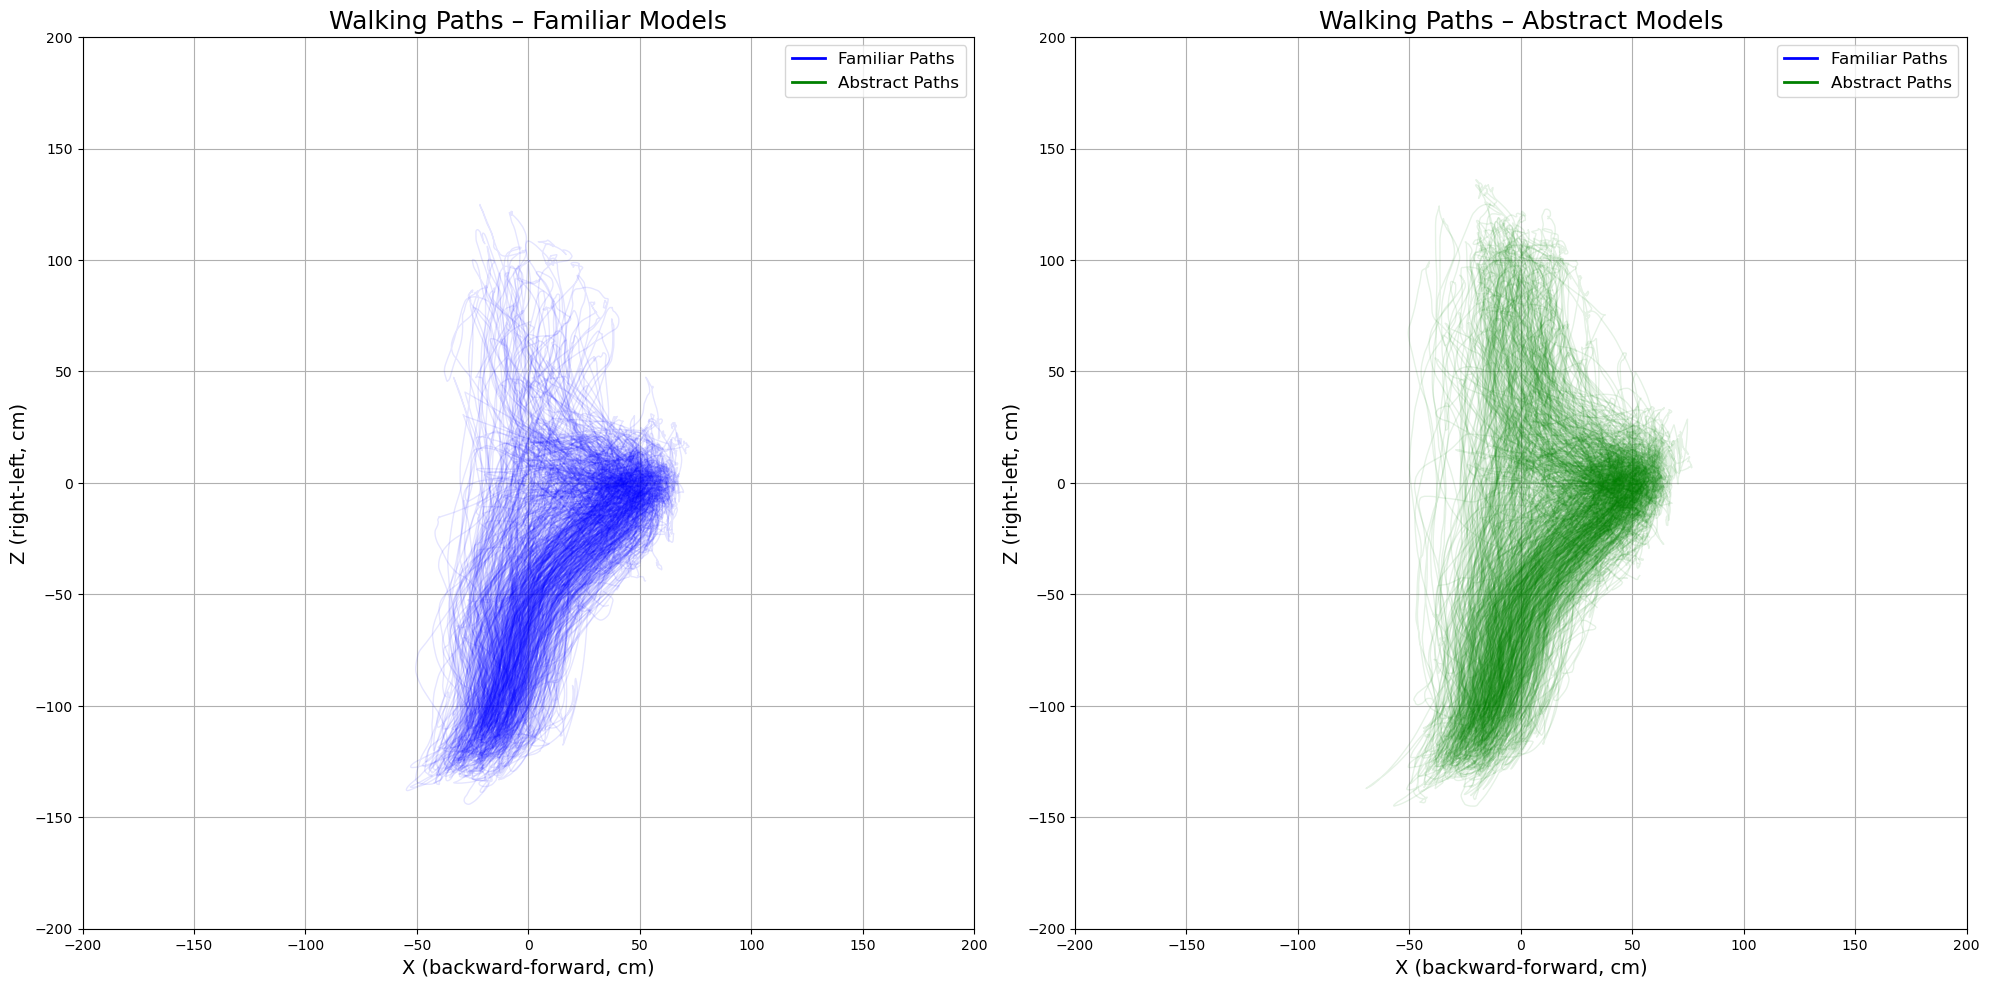

✅ Saved 2-panel overlay plot for selected participants → /Users/lisa/Desktop/8. Semester/Plots/WaistPaths_Familiar_Abstract_Selected.png


In [342]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

# --- Output setup ---
output_dir = "/Users/lisa/Desktop/8. Semester/Plots"
os.makedirs(output_dir, exist_ok=True)

# --- Define model groups by familiarity ---
model_groups = [
    ["C1M1F", "C1M3F", "C1M5F", "C2M3F", "C2M1F", "C2M5F", "C3M5F", "C3M3F", "C3M1F"],  # Familiar
    ["C1M6A", "C1M4A", "C1M2A", "C2M2A", "C2M6A", "C2M4A", "C3M6A", "C3M2A", "C3M4A"],  # Abstract
]

titles = [
    "Familiar Models",
    "Abstract Models"
]

# --- Manually select participants to include ---
selected_participants = [1,2,3,4,5,6,7,8,9,10]  # Adjust as needed

# --- Color mapping ---
familiarity_colors = {0: "blue", 1: "green"}

# --- Plot setup: 1 row, 2 columns ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for i, model_list in enumerate(model_groups):
    ax = axes[i]
    ax.set_title(f"Walking Paths – {titles[i]}", fontsize=18)
    ax.set_xlabel("X (backward-forward, cm)", fontsize=14)
    ax.set_ylabel("Z (right-left, cm)", fontsize=14)
    ax.set_xlim(-200, 200)
    ax.set_ylim(-200, 200)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    for pid in selected_participants:
        init_lf_x = init_lf_z = init_rf_x = init_rf_z = init_waist_x = init_waist_z = None

        for model_name in model_list:
            segment = df_filtered[(df_filtered["model_name"] == model_name) & (df_filtered["Participant"] == pid)]
            if segment.empty:
                print(f"⚠️ No data for model '{model_name}' and participant {pid}")
                continue

            waist_x = segment["Waist_pos_x_smooth"] * 100
            waist_z = segment["Waist_pos_z_smooth"] * 100

            # Save initial waist position from first valid model
            if init_waist_x is None and not waist_x.empty:
                init_waist_x = waist_x.iloc[0]
                init_waist_z = waist_z.iloc[0]

            # --- Plot waist path with familiarity color ---
            ax.plot(waist_x, waist_z, color=familiarity_colors[i], linewidth=1, alpha=0.1)

    # --- Legend ---
    legend_elements = [
        Line2D([0], [0], color="blue", lw=2, label="Familiar Paths"),
        Line2D([0], [0], color="green", lw=2, label="Abstract Paths"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=12)

plt.tight_layout()

# Save static image
output_file = os.path.join(output_dir, "WaistPaths_Familiar_Abstract_Selected.png")
plt.savefig(output_file, dpi=300)
plt.show()

print(f"✅ Saved 2-panel overlay plot for selected participants → {output_file}")


#### What we see

##### Familiarity
We can see a high density of walks between the resource and work area in both the Familiar and Abtract models.
Interestingly the Model Area gets vsisted less when people worked with familar models

##### Complexity
For the different complexities we see a similar pattern. The more complex the models the more the participants move to the model area. While the lowest complexity shows very little walks to the model area the highest complexity shows many visits.

**Converting the Unix Timestamp into real time**

In [ ]:
# converting the Unix timestemp to the real time
# Example timestamp in milliseconds

timestamp_ms = 1755092353721

# Convert to seconds
timestamp_s = timestamp_ms / 1000

# Create datetime object
dt = datetime.fromtimestamp(timestamp_s)

# Extract milliseconds
milliseconds = int(timestamp_ms % 1000)

# Combine into a single string with milliseconds
readable_time_with_ms = dt.strftime("%a %b %d %Y %H:%M:%S") + f".{milliseconds:03d}"

print("Readable time with milliseconds:", readable_time_with_ms)

## **Walking path of all participant for the Visibility conditions**

⚠️ Participant 6 has 15 usable models (expected 18)
⚠️ Participant 7 has 17 usable models (expected 18)
⚠️ Participant 6 has 15 usable models (expected 18)
⚠️ Participant 7 has 17 usable models (expected 18)
⚠️ Participant 6 has 15 usable models (expected 18)
⚠️ Participant 7 has 17 usable models (expected 18)


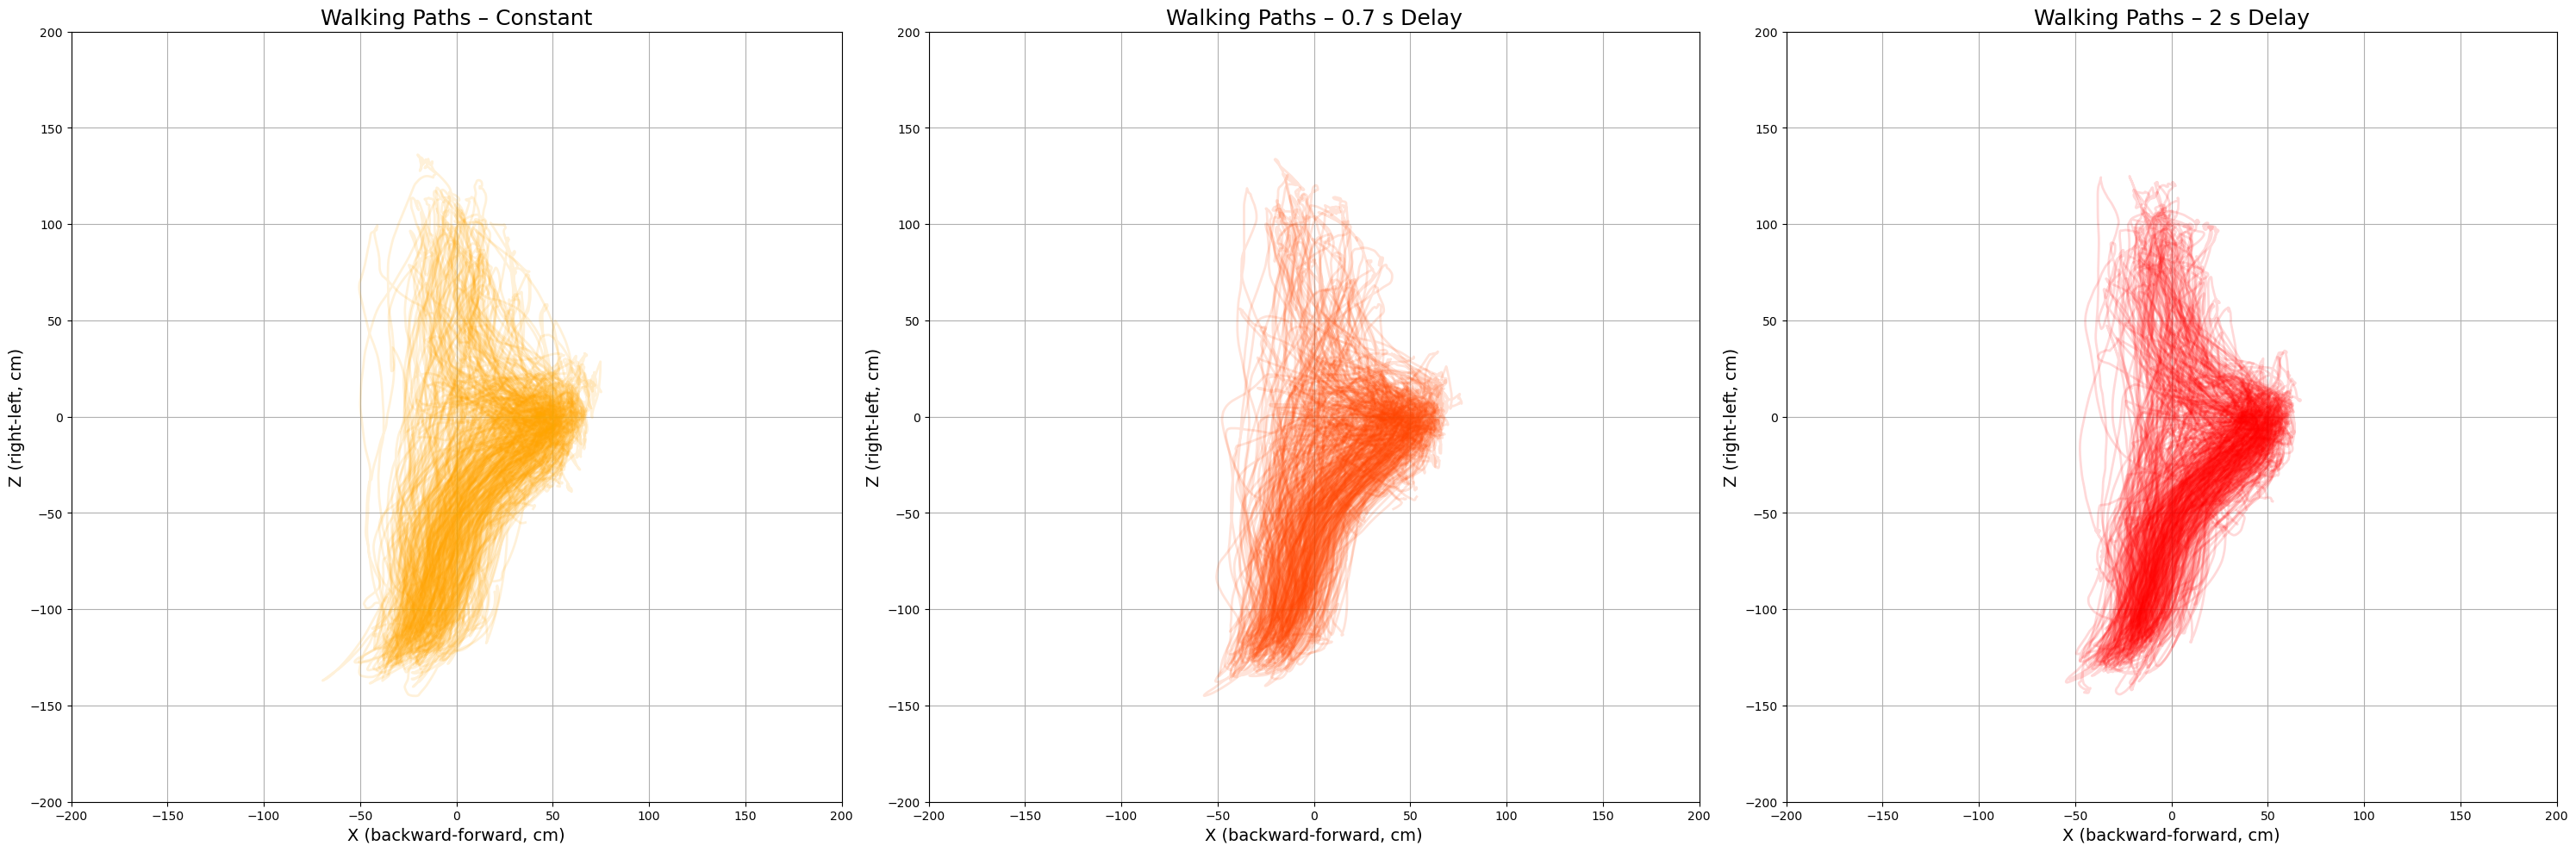

Saved walking path plot by visibility conditions → /Users/lisa/Desktop/8. Semester/WaistPaths_ByVisibility.png


In [343]:
import matplotlib.pyplot as plt
import os

# --- Output setup ---
output_dir = "/Users/lisa/Desktop/8. Semester"
os.makedirs(output_dir, exist_ok=True)

# --- PARTICIPANTS ---
selected_participants = [1,2,3,4,5,6,7,8,9,10]

# --- Plot setup ---
fig, axes = plt.subplots(1, 3, figsize=(30, 10))

# Updated visibility labels
visibility_labels = ["Constant", "0.7 s Delay", "2 s Delay"]

# Colors for each visibility condition
visibility_colors = ["orange", "orangered", "red"]  # blue, orange, green

# --- Loop through visibility conditions ---
for vis_idx, ax in enumerate(axes):
    ax.set_title(f"Walking Paths – {visibility_labels[vis_idx]}", fontsize=18)
    ax.set_xlabel("X (backward-forward, cm)", fontsize=14)
    ax.set_ylabel("Z (right-left, cm)", fontsize=14)
    ax.set_xlim(-200, 200)
    ax.set_ylim(-200, 200)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)

    # Loop through participants
    for pid in selected_participants:
        df_part = df_filtered[df_filtered["Participant"] == pid].sort_values("raw_timestamp")
        model_sequence = (
            df_part.sort_values("raw_timestamp")["model_name"]
            .dropna()
            .loc[lambda x: x != "None"]
            .loc[lambda x: x != "TM"]
            .drop_duplicates()
            .tolist()
        )

        if len(model_sequence) != 18:
            print(f"⚠️ Participant {pid} has {len(model_sequence)} usable models (expected 18)")
            continue

        # Get models for current visibility condition
        vis_models = model_sequence[vis_idx * 6 : (vis_idx + 1) * 6]

        for model in vis_models:
            segment = df_part[df_part["model_name"] == model]
            if segment.empty:
                print(f"⚠️ No data for model '{model}' and participant {pid}")
                continue

            waist_x = segment["Waist_pos_x_smooth"] * 100
            waist_z = segment["Waist_pos_z_smooth"] * 100

            # Plot path with visibility-specific color
            ax.plot(
                waist_x,
                waist_z,
                linewidth=2,
                color=visibility_colors[vis_idx],
                alpha=0.15
            )

plt.tight_layout()

# Save static image
output_file = os.path.join(output_dir, "WaistPaths_ByVisibility.png")
plt.savefig(output_file, dpi=300)
plt.show()

print(f"Saved walking path plot by visibility conditions → {output_file}")


## **Walking path and still standing makers**

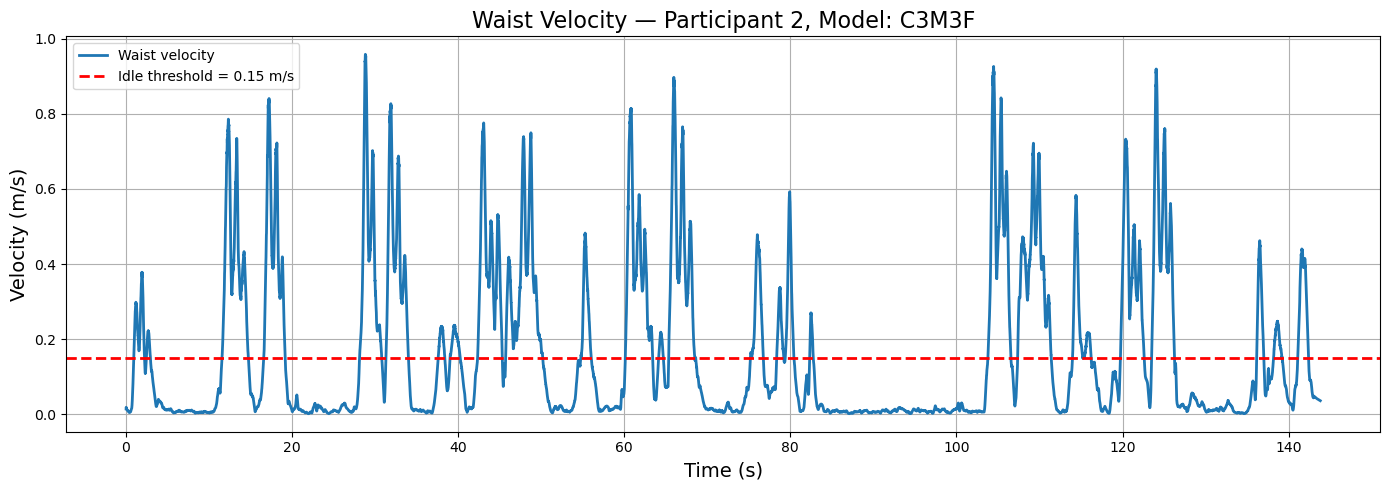

In [344]:
import numpy as np
import matplotlib.pyplot as plt

def plot_waist_velocity_single_sequence(
    df,
    participant_id,
    model_name,
    threshold=0.1,
    smooth_window=5
    ):
    # --- Select data ---
    df_sub = df[
        (df["Participant"] == participant_id) &
        (df["model_name"] == model_name)
    ].copy()

    if df_sub.empty:
        raise ValueError("No data found for this participant/model.")

    # --- Time in seconds ---
    df_sub["time_s"] = (
        df_sub["raw_timestamp"] - df_sub["raw_timestamp"].iloc[0]
    ) / 1000.0

    df_sub["delta_t"] = df_sub["raw_timestamp"].diff() / 1000.0
    df_sub["delta_t"] = df_sub["delta_t"].replace(0, np.nan)

    # --- Velocity computation (same as your pipeline) ---
    dx = df_sub["Waist_pos_x_smooth"].diff()
    dy = df_sub["Waist_pos_y_smooth"].diff()
    dz = df_sub["Waist_pos_z_smooth"].diff()

    df_sub["speed"] = np.sqrt(dx**2 + dy**2 + dz**2) / df_sub["delta_t"]

    df_sub["speed_smooth"] = df_sub["speed"].rolling(
        window=smooth_window,
        min_periods=1
    ).mean()

    # --- Plot ---
    plt.figure(figsize=(14, 5))

    plt.plot(
        df_sub["time_s"],
        df_sub["speed_smooth"],
        label="Waist velocity",
        linewidth=2
    )

    # Threshold line
    plt.axhline(
        threshold,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Idle threshold = {threshold:.2f} m/s"
    )

    plt.xlabel("Time (s)", fontsize=14)
    plt.ylabel("Velocity (m/s)", fontsize=14)
    plt.title(
        f"Waist Velocity — Participant {participant_id}, Model: {model_name}",
        fontsize=16
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_waist_velocity_single_sequence(
    df=df_filtered,
    participant_id=2,
    model_name="C3M3F",
    threshold=0.15,
    smooth_window=10
)

/opt/miniconda3/envs/fraunhofer_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(
/opt/miniconda3/envs/fraunhofer_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(


IndexError: list index out of range

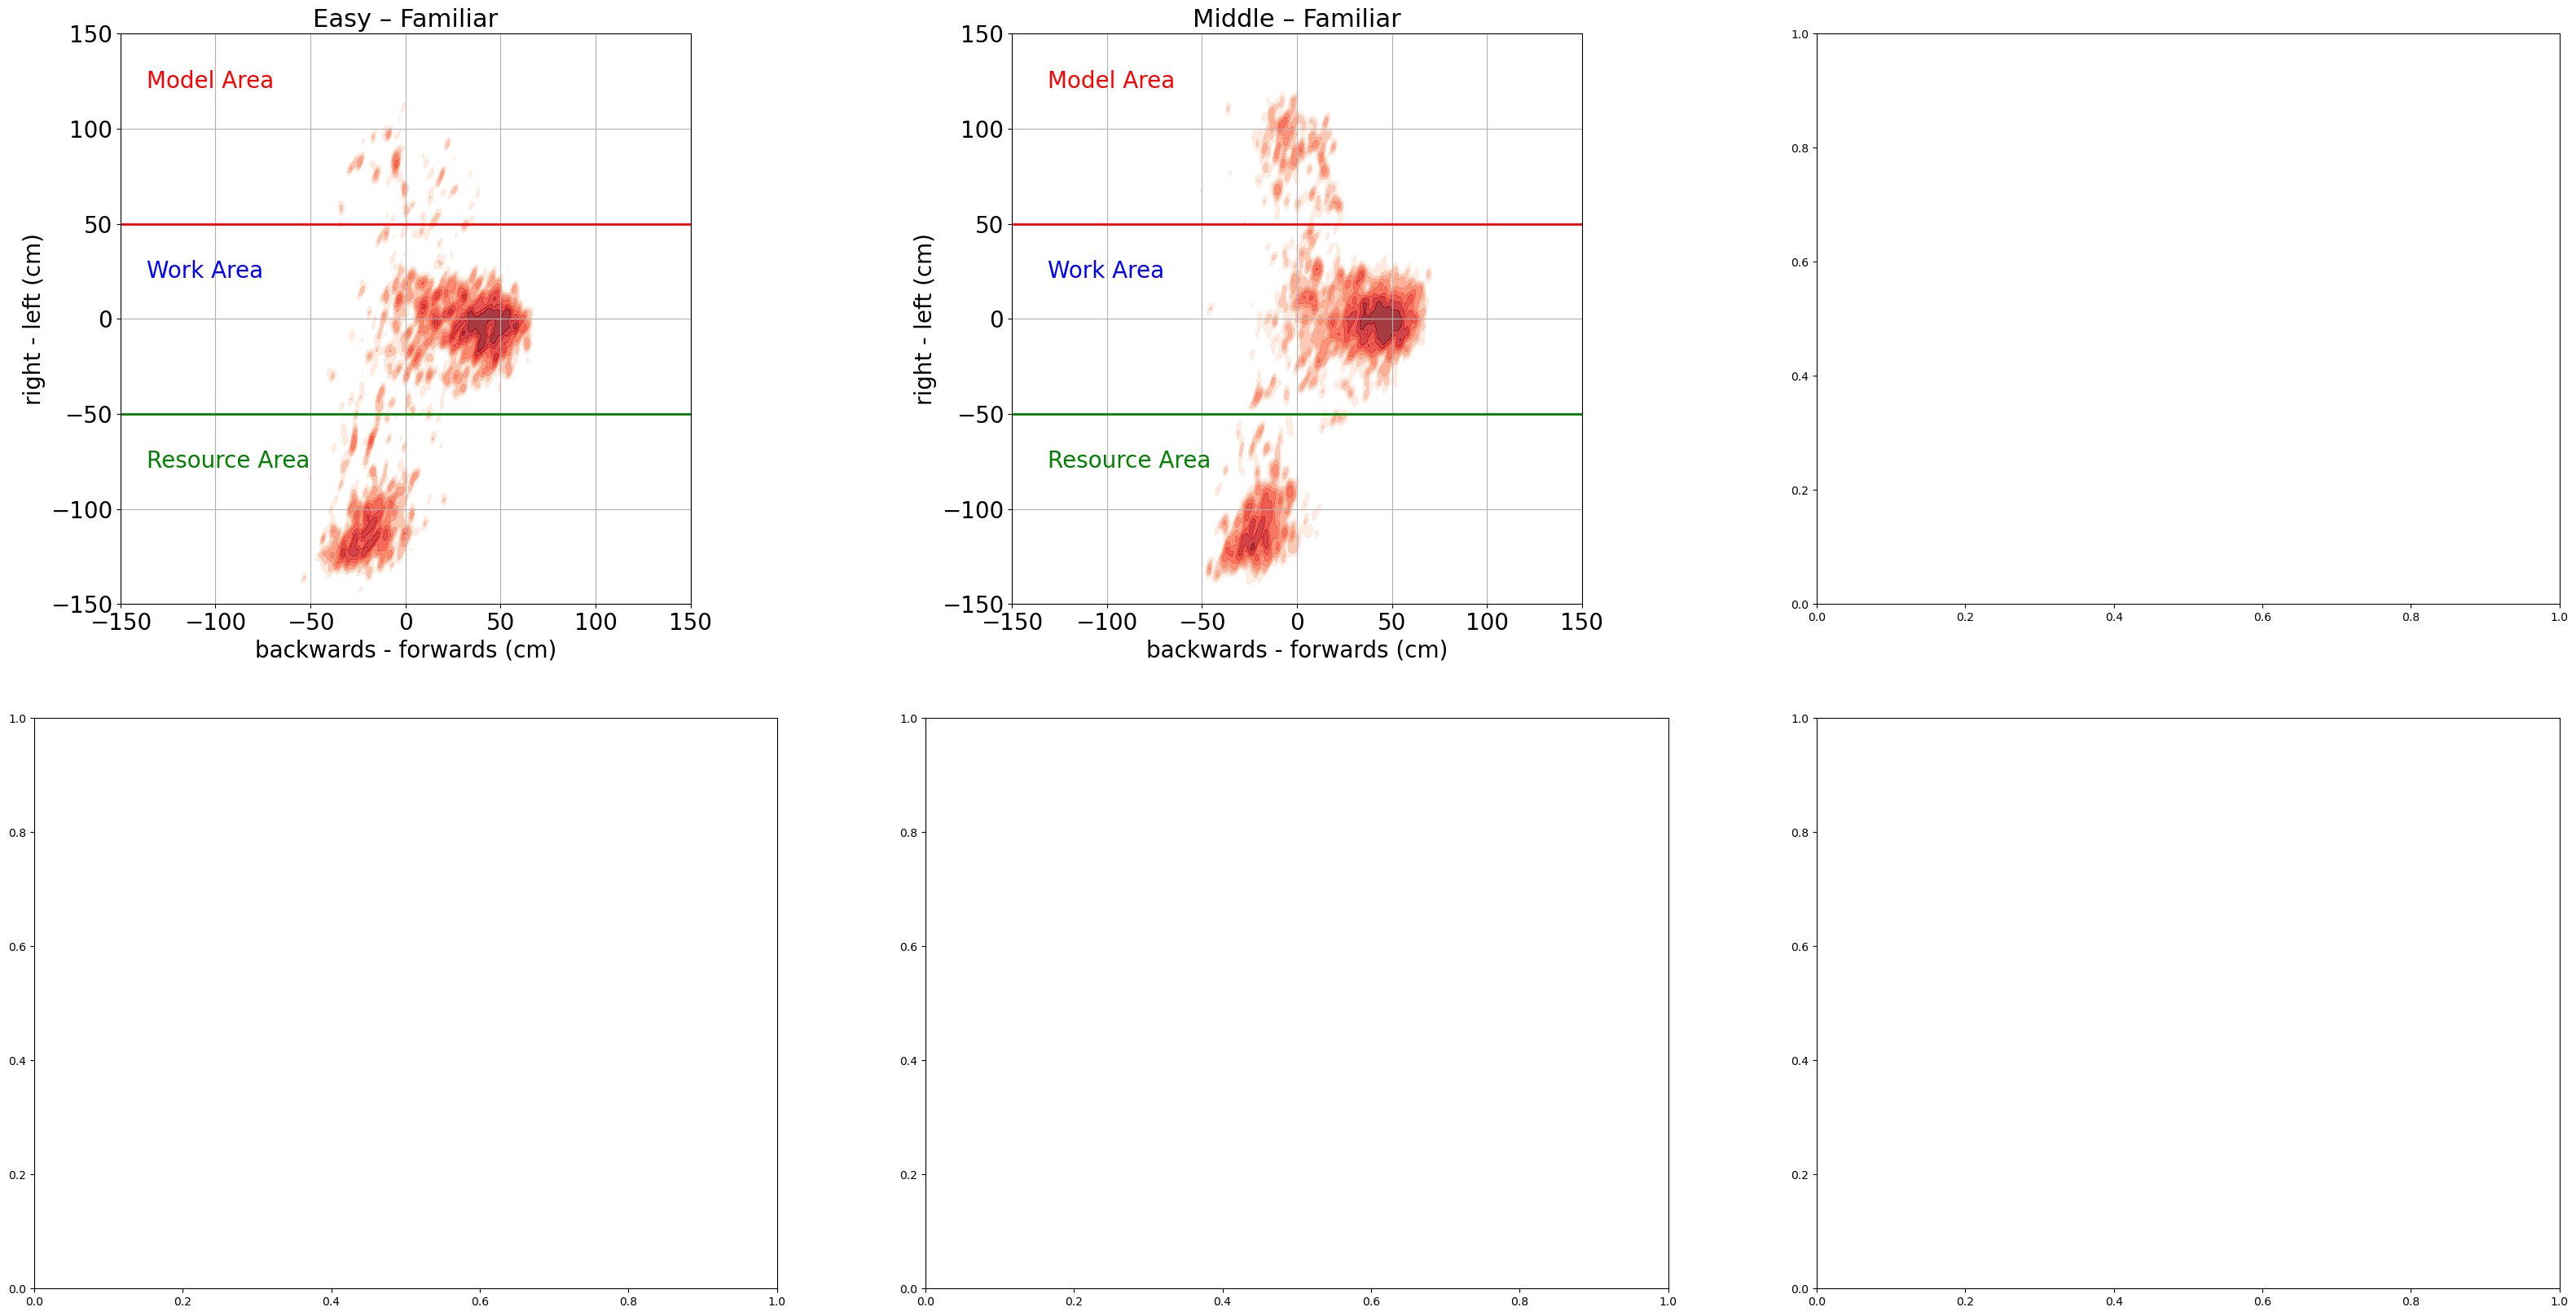

In [345]:
def plot_paths_by_model_group(df, participant_ids, group_idx, ax,
                              model_groups,
                              threshold=0.3, smooth_window=1):

    model_names = model_groups[group_idx]

    all_x, all_z = [], []

    # NEW: counters
    total_stops = 0
    model_area_stops = 0
    work_area_stops = 0
    resource_area_stops = 0

    for pid in participant_ids:
        df_sub = df[(df['Participant'] == pid) &
                    (df['model_name'].isin(model_names))].copy()

        if df_sub.empty:
            continue

        df_sub['time_seconds'] = (
            df_sub['raw_timestamp'] - df_sub['raw_timestamp'].iloc[0]
        ) / 1000.0
        df_sub['delta_t'] = df_sub['raw_timestamp'].diff() / 1000.0
        df_sub['delta_t'] = df_sub['delta_t'].replace(0, np.nan)

        dx = df_sub['Waist_pos_x_smooth'].diff()
        dy = df_sub['Waist_pos_y_smooth'].diff()
        dz = df_sub['Waist_pos_z_smooth'].diff()

        df_sub['speed'] = np.sqrt(dx**2 + dy**2 + dz**2) / df_sub['delta_t']
        df_sub['speed_smooth'] = df_sub['speed'].rolling(
            window=smooth_window, min_periods=1
        ).mean()

        standing_mask = df_sub['speed_smooth'] < threshold

        df_sub["is_stop"] = standing_mask.astype(int)
        df_sub["segment_change"] = df_sub["is_stop"].diff().fillna(0)

        start_indices = df_sub.index[df_sub["segment_change"] == 1].tolist()
        if standing_mask.iloc[0]:
            start_indices.insert(0, df_sub.index[0])

        end_indices = df_sub.index[df_sub["segment_change"] == -1].tolist()
        if standing_mask.iloc[-1]:
            end_indices.append(df_sub.index[-1])

        # ---- Count stops ----
        for start, end in zip(start_indices, end_indices):
            seg = df_sub.loc[start:end]
            midpoint_idx = seg.index[len(seg) // 2]

            x_mid = df_sub.loc[midpoint_idx, "Waist_pos_x_smooth"] * 100
            z_mid = df_sub.loc[midpoint_idx, "Waist_pos_z_smooth"] * 100

            all_x.append(x_mid)
            all_z.append(z_mid)

            total_stops += 1

            if z_mid > 50:
                model_area_stops += 1
            elif z_mid < -50:
                resource_area_stops += 1
            else:
                work_area_stops += 1

    # KDE plot
    if len(all_x) > 0 and len(all_z) > 0:
        sns.kdeplot(
            x=all_x, y=all_z,
            fill=True,
            cmap="Reds",
            alpha=0.8,
            bw_adjust=0.15,
            levels=10,
            thresh=0.0,
            norm=LogNorm(),
            ax=ax
        )

    # Boundary lines + labels
    ax.axhline(50, color="red", linewidth=2)
    ax.axhline(-50, color="green", linewidth=2)

    xlim = ax.get_xlim()

    ax.text(xlim[1] - 210, 125, "Model Area",
            va="center", ha="left", fontsize=20, color="red")
    ax.text(xlim[1] - 210, 25, "Work Area",
            va="center", ha="left", fontsize=20, color="blue")
    ax.text(xlim[1] - 210, -75, "Resource Area",
            va="center", ha="left", fontsize=20, color="green")

    ax.set_xlim(xlim[0], xlim[1] + 80)

    ax.set_xlim(-150, 150)
    ax.set_ylim(-150, 150)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_title(group_labels[group_idx], fontsize=22)
    ax.set_xlabel("backwards - forwards (cm)", fontsize=20)
    ax.set_ylabel("right - left (cm)", fontsize=20)
    ax.grid(True)

    # ---- NEW: return summary counts ----
    return {
        "Model_Group": group_labels[group_idx],
        "Total_Stops": total_stops,
        "Model_Area": model_area_stops,
        "Work_Area": work_area_stops,
        "Resource_Area": resource_area_stops
    }
summaries = []

fig, axes = plt.subplots(2, 3, figsize=(40, 20))
participant_ids = [2,3,4,5,8,9,10]

for i in range(6):
    row = i // 3
    col = i % 3

    summary = plot_paths_by_model_group(
        df_filtered,
        participant_ids,
        i,
        ax=axes[row][col],
        model_groups=model_groups
    )

    summaries.append(summary)

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summaries)
print(summary_df)


/opt/miniconda3/envs/fraunhofer_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(
/opt/miniconda3/envs/fraunhofer_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(
/opt/miniconda3/envs/fraunhofer_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(


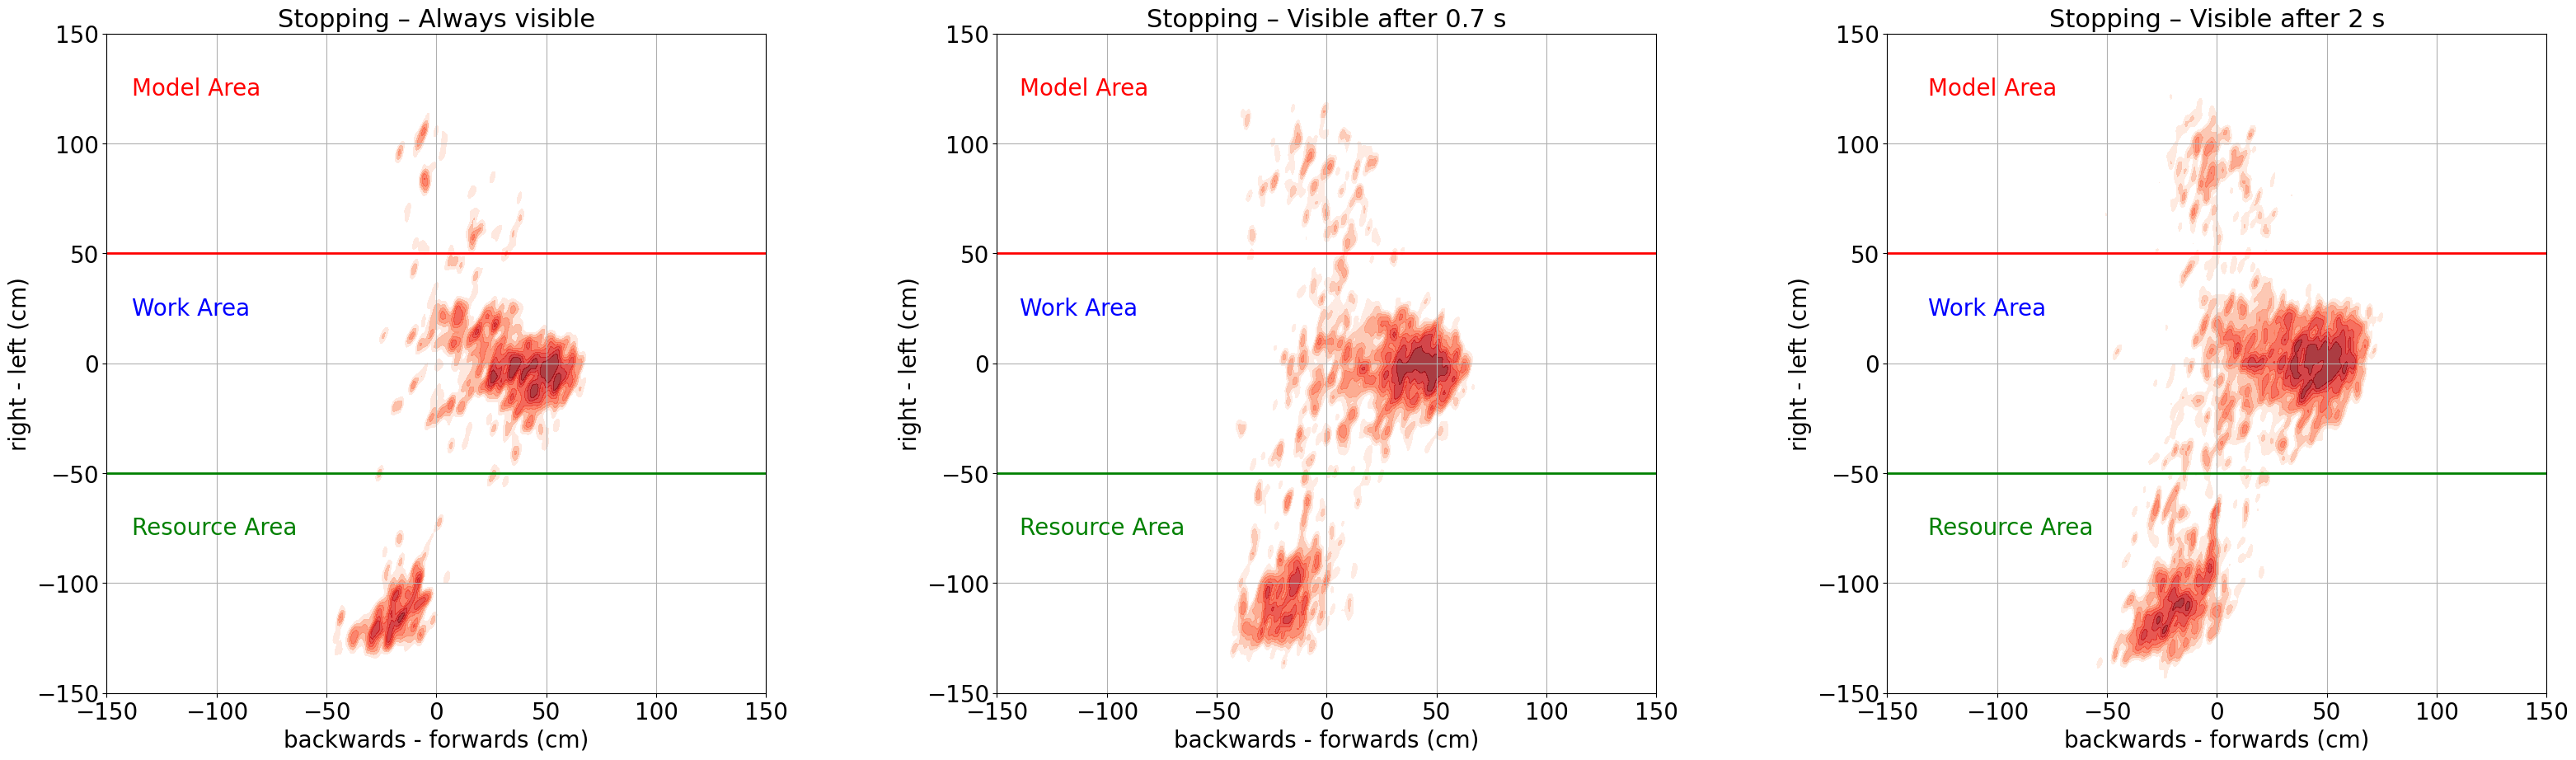

            Visibility  Total_Stops  Model_Area  Work_Area  Resource_Area
0       Always visible         1520         100       1054            366
1  Visible after 0.7 s         3304         306       2096            902
2    Visible after 2 s         5330         510       3264           1556


In [263]:
import re

def natural_sort_key(s):
    """Sort strings containing numbers in human order."""
    return [int(text) if text.isdigit() else text.lower() 
            for text in re.split(r'(\d+)', s)]

def plot_paths_by_visibility(df, participant_ids, visibility_idx, ax,
                             threshold=0.3, smooth_window=1):

    # ----- CLEAN + SORT MODEL NAMES -----
    all_model_names = (
        df['model_name']
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    all_model_names = [m for m in all_model_names if m.lower() != "nan"]
    all_model_names = sorted(all_model_names, key=natural_sort_key)

    start = visibility_idx * 6
    end = start + 6
    model_names = all_model_names[start:end]

    if len(model_names) < 6:
        ax.set_title(f"Not enough models for visibility {visibility_idx}")
        return None

    # ------------ Collect standing points ------------
    all_x, all_z = [], []

    # NEW: counters
    total_stops = 0
    model_area_stops = 0
    work_area_stops = 0
    resource_area_stops = 0

    for pid in participant_ids:
        df_sub = df[(df['Participant'] == pid) &
                    (df['model_name'].isin(model_names))].copy()

        if df_sub.empty:
            continue

        df_sub['time_seconds'] = (
            df_sub['raw_timestamp'] - df_sub['raw_timestamp'].iloc[0]
        ) / 1000.0
        df_sub['delta_t'] = df_sub['raw_timestamp'].diff() / 1000.0
        df_sub['delta_t'] = df_sub['delta_t'].replace(0, np.nan)

        dx = df_sub['Waist_pos_x_smooth'].diff()
        dy = df_sub['Waist_pos_y_smooth'].diff()
        dz = df_sub['Waist_pos_z_smooth'].diff()

        df_sub['speed'] = np.sqrt(dx**2 + dy**2 + dz**2) / df_sub['delta_t']
        df_sub['speed_smooth'] = df_sub['speed'].rolling(
            window=smooth_window, min_periods=1
        ).mean()

        standing_mask = df_sub['speed_smooth'] < threshold

        df_sub["is_stop"] = standing_mask.astype(int)
        df_sub["segment_change"] = df_sub["is_stop"].diff().fillna(0)

        start_indices = df_sub.index[df_sub["segment_change"] == 1].tolist()
        if standing_mask.iloc[0]:
            start_indices.insert(0, df_sub.index[0])

        end_indices = df_sub.index[df_sub["segment_change"] == -1].tolist()
        if standing_mask.iloc[-1]:
            end_indices.append(df_sub.index[-1])

        # ---- Count stops ----
        for start, end in zip(start_indices, end_indices):
            seg = df_sub.loc[start:end]
            midpoint_idx = seg.index[len(seg) // 2]

            x_mid = df_sub.loc[midpoint_idx, "Waist_pos_x_smooth"] * 100
            z_mid = df_sub.loc[midpoint_idx, "Waist_pos_z_smooth"] * 100

            all_x.append(x_mid)
            all_z.append(z_mid)

            total_stops += 1

            if z_mid > 50:
                model_area_stops += 1
            elif z_mid < -50:
                resource_area_stops += 1
            else:
                work_area_stops += 1

    # ------------ KDE plot ------------
    if len(all_x) > 0 and len(all_z) > 0:
        sns.kdeplot(
            x=all_x, y=all_z,
            fill=True,
            cmap="Reds",
            alpha=0.8,
            bw_adjust=0.15,
            levels=10,
            thresh=0.0,
            norm=LogNorm(),
            ax=ax
        )

    # Boundary lines + labels
    ax.axhline(50, color="red", linewidth=2)
    ax.axhline(-50, color="green", linewidth=2)

    xlim = ax.get_xlim()

    ax.text(xlim[1] - 210, 125, "Model Area",
            va="center", ha="left", fontsize=20, color="red")
    ax.text(xlim[1] - 210, 25, "Work Area",
            va="center", ha="left", fontsize=20, color="blue")
    ax.text(xlim[1] - 210, -75, "Resource Area",
            va="center", ha="left", fontsize=20, color="green")

    ax.set_xlim(xlim[0], xlim[1] + 80)

    labels = [
        "Always visible",
        "Visible after 0.7 s",
        "Visible after 2 s"
    ]

    ax.set_xlim(-150, 150)
    ax.set_ylim(-150, 150)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_title(f"Stopping – {labels[visibility_idx]}", fontsize=22)
    ax.set_xlabel("backwards - forwards (cm)", fontsize=20)
    ax.set_ylabel("right - left (cm)", fontsize=20)
    ax.grid(True)

    # ---- NEW: return summary ----
    return {
        "Visibility": labels[visibility_idx],
        "Total_Stops": total_stops,
        "Model_Area": model_area_stops,
        "Work_Area": work_area_stops,
        "Resource_Area": resource_area_stops
    }
participant_ids = [1,2,3,4,5,8,9,10]

fig, axes = plt.subplots(1, 3, figsize=(36, 10))

summaries = []

for i in range(3):
    summary = plot_paths_by_visibility(
        df_filtered,
        participant_ids,
        i,
        ax=axes[i]
    )
    summaries.append(summary)

# Move axes closer
axes[0].set_position([0.05, 0.1, 0.28, 0.8])
axes[1].set_position([0.35, 0.1, 0.28, 0.8])
axes[2].set_position([0.65, 0.1, 0.28, 0.8])

plt.show()

visibility_summary_df = pd.DataFrame(summaries)
print(visibility_summary_df)


#### What we see for the Visibility changes

We are depicting here a KDE plot for the standing still areas. Meaing the dark red spots show the places where participants have made the most stops. This does not show the duration of stops but only the amount of stops taken in the area. We can see here that there is an intersting change in the amount of stops taken when the Familiarty of the model changes. Stopping here means everytime the speed of the participant is lower than 1.5 ms.


We can see also the same changes for the Visibility conditions.

## **Visit Extraction Per Participant & Model Dataframe**

In [346]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/lisa/Desktop/8. Semester/Data/area_visits_per_model.csv")

# ---- Collapse to participant × model × area ----
area_model_df = (
    df
    .groupby([
        "participant",
        "model_name",
        "area",
        "condition",
        "complexity",
        "familiarity"
    ])
    .agg(
        n_visits=("visit", "count"),          # number of visits
        total_duration=("duration", "sum")    # total time spent
    )
    .reset_index()
)

area_model_df.head()

,participant,model_name,area,condition,complexity,familiarity,n_visits,total_duration
0,1,C1M1F,Resource,0.7_Delay,Easy,Familiar,1,11.588
1,1,C1M1F,Work,0.7_Delay,Easy,Familiar,2,59.694
2,1,C1M2A,Model,Constant,Easy,Abstract,1,2.435
3,1,C1M2A,Resource,Constant,Easy,Abstract,2,12.409
4,1,C1M2A,Work,Constant,Easy,Abstract,4,33.973


## **Bar plots for mean visits**

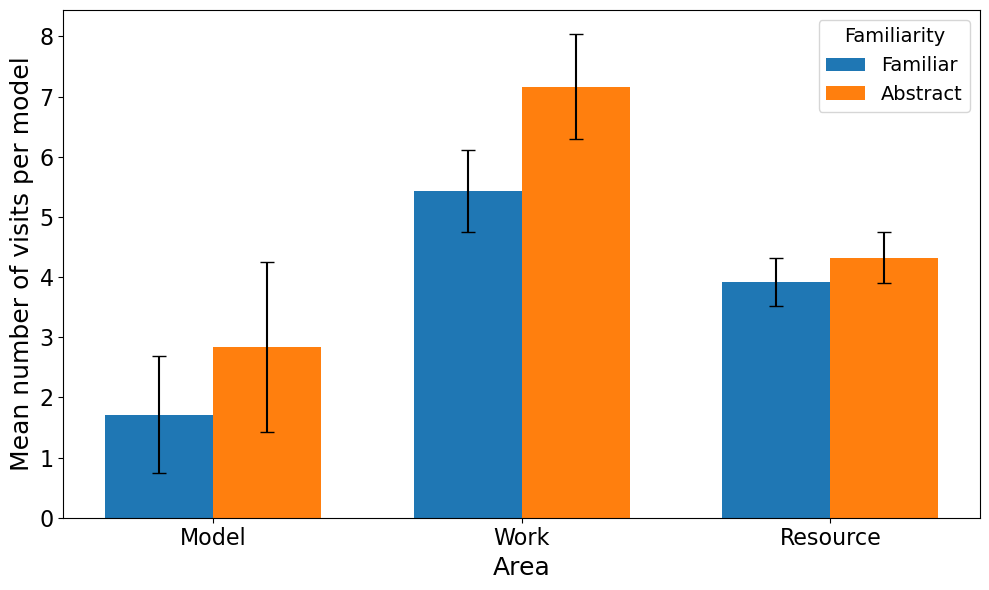


Summary of means and standard deviations:
  Familiarity      Area      Mean       Std
0    Familiar     Model  1.711806  0.973405
1    Familiar      Work  5.431548  0.675933
2    Familiar  Resource  3.918254  0.393212
3    Abstract     Model  2.843532  1.413324
4    Abstract      Work  7.163889  0.871989
5    Abstract  Resource  4.320833  0.428157


In [425]:
#----------------------------------------------------
# This is for Visits and familiarity
#----------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# LOAD AGGREGATED DATA
# ---------------------------
df = area_model_df

areas = ["Model", "Work", "Resource"]
familiarities = ["Familiar", "Abstract"]
conditions = ["Constant", "0.7_Delay", "2_Delay"]
complexities = ["Easy", "Medium", "Hard"]

# ---------------------------
# AGGREGATE TO PARTICIPANT LEVEL
# ---------------------------
mean_visits = []
std_visits = []

for fam in familiarities:
    df_fam = df[df["familiarity"] == fam]

    fam_means = []
    fam_stds = []

    for area in areas:
        df_area = df_fam[df_fam["area"] == area]

        # mean visits per model for each participant
        visits_per_participant = (
            df_area
            .groupby("participant")["n_visits"]
            .mean()
            .dropna()
        )

        fam_means.append(visits_per_participant.mean())
        fam_stds.append(visits_per_participant.std())

    mean_visits.append(fam_means)
    std_visits.append(fam_stds)

mean_visits = np.array(mean_visits)
std_visits = np.array(std_visits)

# ---------------------------
# PLOT
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 6))


x = np.arange(len(areas))
width = 0.35

for i, fam in enumerate(familiarities):
    ax.bar(
        x + i * width,
        mean_visits[i],
        width,
        yerr=std_visits[i],
        capsize=5,
        label=fam
    )

# ---------------------------
# LABELS & STYLE
# ---------------------------
ax.set_ylabel("Mean number of visits per model", fontsize=18)
ax.set_xlabel("Area", fontsize=18)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(areas, fontsize=16)

ax.tick_params(axis="y", labelsize=16)

ax.legend(
    title="Familiarity",
    fontsize=14,
    title_fontsize=14
)

plt.tight_layout()
plt.show()

# ---------------------------
# SUMMARY DATAFRAME
# ---------------------------
summary_df = pd.DataFrame(
    {
        "Familiarity": np.repeat(familiarities, len(areas)),
        "Area": areas * len(familiarities),
        "Mean": mean_visits.flatten(),
        "Std": std_visits.flatten()
    }
)

print("\nSummary of means and standard deviations:")
print(summary_df)


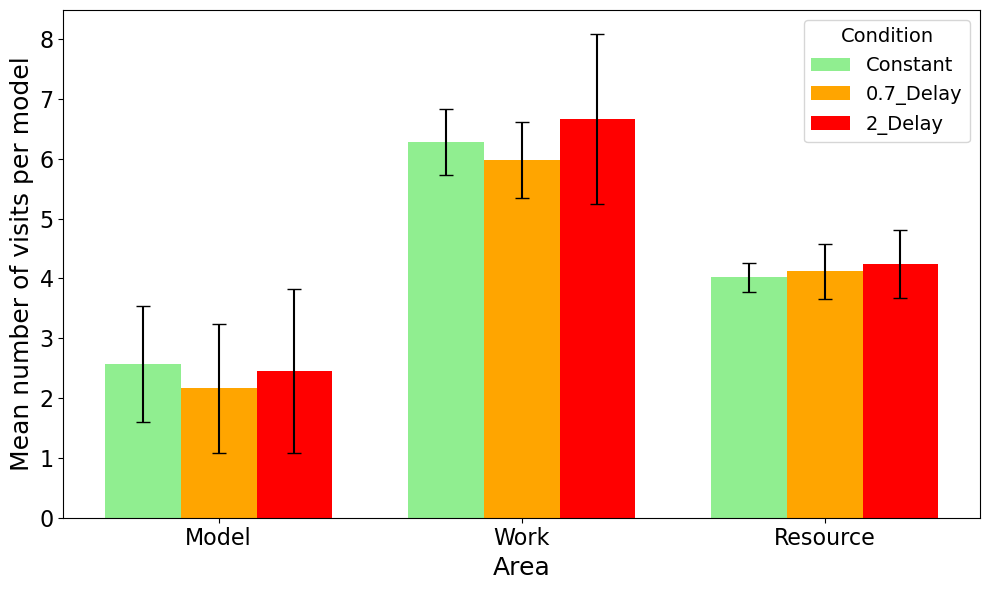


Summary of means and standard deviations:
   Condition      Area      Mean       Std
0   Constant     Model  2.566667  0.972460
1   Constant      Work  6.283333  0.550252
2   Constant  Resource  4.016667  0.241523
3  0.7_Delay     Model  2.163333  1.076311
4  0.7_Delay      Work  5.983333  0.635620
5  0.7_Delay  Resource  4.116667  0.465143
6    2_Delay     Model  2.451667  1.364009
7    2_Delay      Work  6.660000  1.423073
8    2_Delay  Resource  4.243333  0.570477


In [423]:
#----------------------------------------------------
# This is for Visits and condition
#----------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# LOAD AGGREGATED DATA
# ---------------------------
df = area_model_df

areas = ["Model", "Work", "Resource"]
conditions = ["Constant", "0.7_Delay", "2_Delay"]

# ---------------------------
# AGGREGATE TO PARTICIPANT LEVEL
# ---------------------------
mean_visits = []
std_visits = []

for cond in conditions:
    df_cond = df[df["condition"] == cond]

    cond_means = []
    cond_stds = []

    for area in areas:
        df_area = df_cond[df_cond["area"] == area]

        # mean visits per model for each participant
        visits_per_participant = (
            df_area
            .groupby("participant")["n_visits"]
            .mean()
            .dropna()
        )

        cond_means.append(visits_per_participant.mean())
        cond_stds.append(visits_per_participant.std())

    mean_visits.append(cond_means)
    std_visits.append(cond_stds)

mean_visits = np.array(mean_visits)
std_visits = np.array(std_visits)

# ---------------------------
# PLOT
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 6))

condition_colors = {
    "Constant": "lightgreen",
    "0.7_Delay": "orange",
    "2_Delay": "red"
}


x = np.arange(len(areas))
width = 0.25  # 3 conditions → narrower bars

for i, cond in enumerate(conditions):
    ax.bar(
        x + i * width,
        mean_visits[i],
        width,
        yerr=std_visits[i],
        capsize=5,
        label=cond,
        color=condition_colors[cond]   # ← ADD THIS
    )


# ---------------------------
# LABELS & STYLE
# ---------------------------
ax.set_ylabel("Mean number of visits per model", fontsize=18)
ax.set_xlabel("Area", fontsize=18)

ax.set_xticks(x + width)
ax.set_xticklabels(areas, fontsize=16)

ax.tick_params(axis="y", labelsize=16)

ax.legend(
    title="Condition",
    fontsize=14,
    title_fontsize=14
)

plt.tight_layout()
plt.show()

# ---------------------------
# SUMMARY DATAFRAME
# ---------------------------
summary_df = pd.DataFrame(
    {
        "Condition": np.repeat(conditions, len(areas)),
        "Area": areas * len(conditions),
        "Mean": mean_visits.flatten(),
        "Std": std_visits.flatten()
    }
)

print("\nSummary of means and standard deviations:")
print(summary_df)


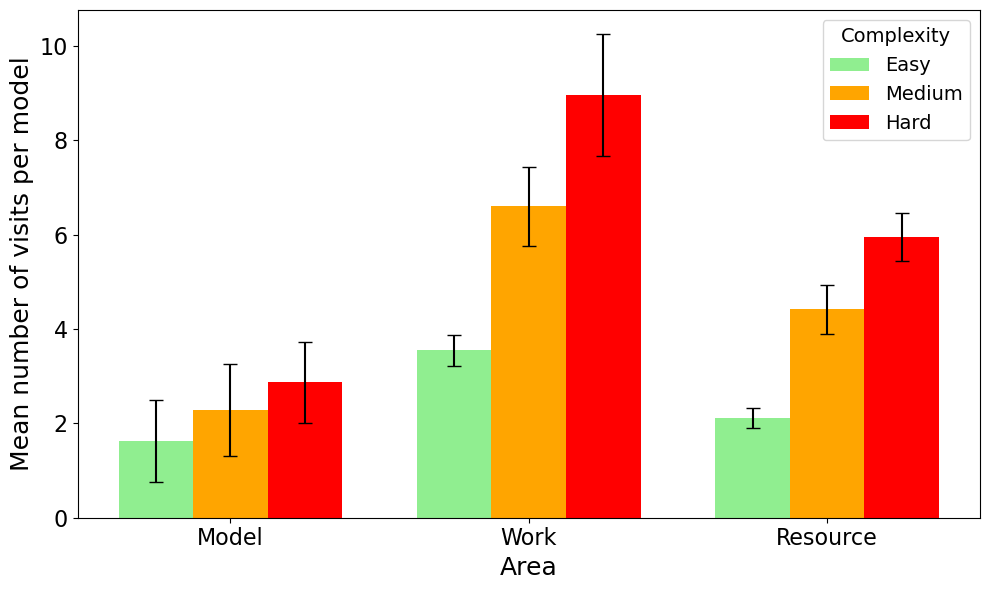


Summary of means and standard deviations:
  Complexity      Area      Mean       Std
0       Easy     Model  1.625000  0.867170
1       Easy      Work  3.550000  0.333796
2       Easy  Resource  2.116667  0.208611
3     Medium     Model  2.291667  0.974402
4     Medium      Work  6.600000  0.843274
5     Medium  Resource  4.416667  0.522636
6       Hard     Model  2.875000  0.856394
7       Hard      Work  8.963333  1.288549
8       Hard  Resource  5.956667  0.507000


In [428]:
#----------------------------------------------------
# This is for Visits and condition
#----------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# LOAD AGGREGATED DATA
# ---------------------------
df = area_model_df

areas = ["Model", "Work", "Resource"]
complexities = ["Easy", "Medium", "Hard"]

# ---------------------------
# AGGREGATE TO PARTICIPANT LEVEL
# ---------------------------
mean_visits = []
std_visits = []

for comp in complexities:
    df_comp = df[df["complexity"] == comp]

    comp_means = []
    comp_stds = []

    for area in areas:
        df_area = df_comp[df_comp["area"] == area]

        # mean visits per model for each participant
        visits_per_participant = (
            df_area
            .groupby("participant")["n_visits"]
            .mean()
            .dropna()
        )

        comp_means.append(visits_per_participant.mean())
        comp_stds.append(visits_per_participant.std())

    mean_visits.append(comp_means)
    std_visits.append(comp_stds)

mean_visits = np.array(mean_visits)
std_visits = np.array(std_visits)

# ---------------------------
# PLOT
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 6))

condition_colors = {
    "Easy": "lightgreen",
    "Medium": "orange",
    "Hard": "red"
}

x = np.arange(len(areas))
width = 0.25  # 3 complexities → narrower bars

for i, comp in enumerate(complexities):
    ax.bar(
        x + i * width,
        mean_visits[i],
        width,
        yerr=std_visits[i],
        capsize=5,
        label=comp,
        color=condition_colors[comp]
    )

# ---------------------------
# LABELS & STYLE
# ---------------------------
ax.set_ylabel("Mean number of visits per model", fontsize=18)
ax.set_xlabel("Area", fontsize=18)

ax.set_xticks(x + width)
ax.set_xticklabels(areas, fontsize=16)

ax.tick_params(axis="y", labelsize=16)

ax.legend(
    title="Complexity",
    fontsize=14,
    title_fontsize=14
)

plt.tight_layout()
plt.show()

# ---------------------------
# SUMMARY DATAFRAME
# ---------------------------
summary_df = pd.DataFrame(
    {
        "Complexity": np.repeat(complexities, len(areas)),
        "Area": areas * len(complexities),
        "Mean": mean_visits.flatten(),
        "Std": std_visits.flatten()
    }
)

print("\nSummary of means and standard deviations:")
print(summary_df)


## **Bar plots for mean duration**

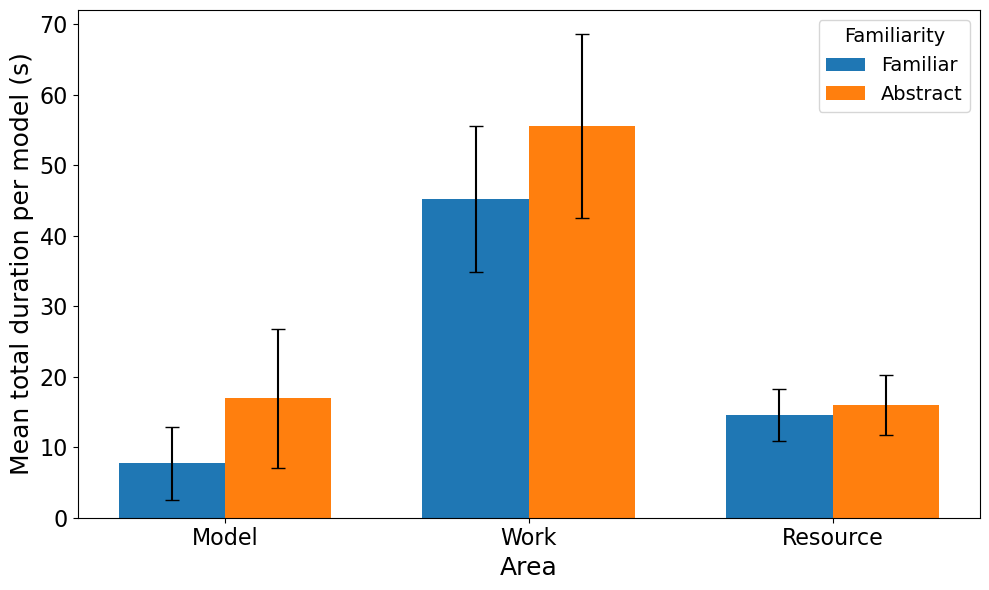


Summary of mean and standard deviation of durations:
  Familiarity      Area  Mean_Duration  Std_Duration
0    Familiar     Model       7.715223      5.167259
1    Familiar      Work      45.202358     10.354549
2    Familiar  Resource      14.584945      3.630836
3    Abstract     Model      16.918074      9.833166
4    Abstract      Work      55.532947     13.061172
5    Abstract  Resource      15.988762      4.240999


In [ ]:
#----------------------------------------------------
# This is for Duration and familiarity
#----------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# LOAD AGGREGATED DATA
# ---------------------------
df = area_model_df

areas = ["Model", "Work", "Resource"]
familiarities = ["Familiar", "Abstract"]
conditions = ["Constant", "0.7_Delay", "2_Delay"]
complexities = ["Easy", "Medium", "Hard"]

# ---------------------------
# AGGREGATE TO PARTICIPANT LEVEL
# ---------------------------
mean_durations = []
std_durations = []

for fam in familiarities:
    df_fam = df[df["familiarity"] == fam]

    fam_means = []
    fam_stds = []

    for area in areas:
        df_area = df_fam[df_fam["area"] == area]

        # total duration per model for each participant
        duration_per_participant = (
            df_area
            .groupby("participant")["total_duration"]
            .mean()  # average across models for each participant
            .dropna()
        )

        fam_means.append(duration_per_participant.mean())
        fam_stds.append(duration_per_participant.std())

    mean_durations.append(fam_means)
    std_durations.append(fam_stds)

mean_durations = np.array(mean_durations)
std_durations = np.array(std_durations)

# ---------------------------
# PLOT
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(areas))
width = 0.35

for i, fam in enumerate(familiarities):
    ax.bar(
        x + i * width,
        mean_durations[i],
        width,
        yerr=std_durations[i],
        capsize=5,
        label=fam
    )

# ---------------------------
# LABELS & STYLE
# ---------------------------
ax.set_ylabel("Mean total duration per model (s)", fontsize=18)
ax.set_xlabel("Area", fontsize=18)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(areas, fontsize=16)

ax.tick_params(axis="y", labelsize=16)

ax.legend(
    title="Familiarity",
    fontsize=14,
    title_fontsize=14
)

plt.tight_layout()
plt.show()

# ---------------------------
# SUMMARY DATAFRAME
# ---------------------------
summary_df = pd.DataFrame(
    {
        "Familiarity": np.repeat(familiarities, len(areas)),
        "Area": areas * len(familiarities),
        "Mean_Duration": mean_durations.flatten(),
        "Std_Duration": std_durations.flatten()
    }
)

print("\nSummary of mean and standard deviation of durations:")
print(summary_df)


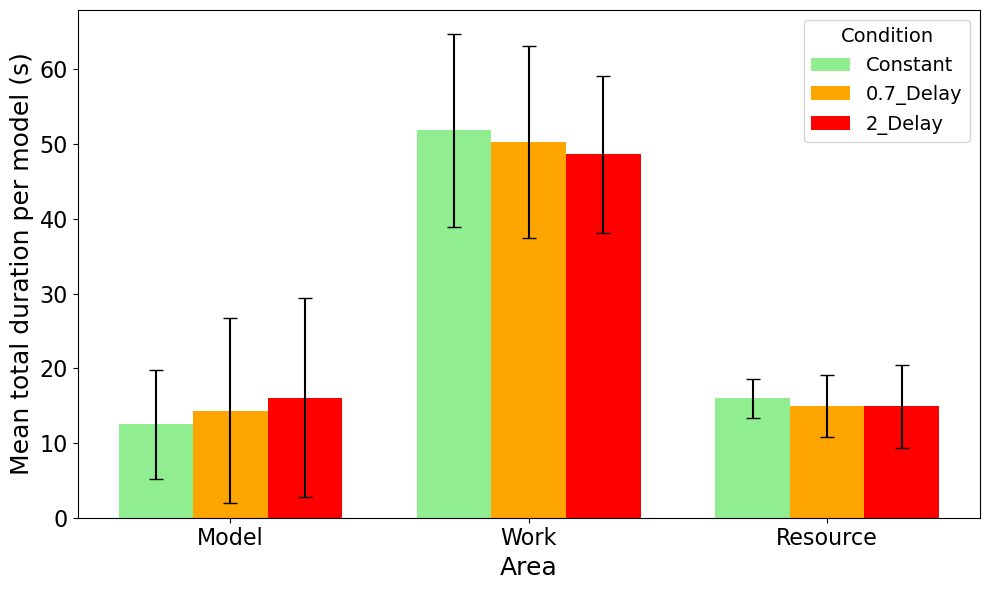


Summary of mean and standard deviation of durations:
   Condition      Area  Mean_Duration  Std_Duration
0   Constant     Model      12.477833      7.289604
1   Constant      Work      51.817300     12.888645
2   Constant  Resource      15.984800      2.600129
3  0.7_Delay     Model      14.340560     12.420227
4  0.7_Delay      Work      50.262767     12.853265
5  0.7_Delay  Resource      14.914483      4.119702
6    2_Delay     Model      16.075088     13.275186
7    2_Delay      Work      48.623313     10.516117
8    2_Delay  Resource      14.908800      5.534520


In [429]:
#----------------------------------------------------
# This is for Duration and condition
#----------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# LOAD AGGREGATED DATA
# ---------------------------
df = area_model_df

areas = ["Model", "Work", "Resource"]
conditions = ["Constant", "0.7_Delay", "2_Delay"]

# ---------------------------
# AGGREGATE TO PARTICIPANT LEVEL
# ---------------------------
mean_durations = []
std_durations = []

for cond in conditions:
    df_cond = df[df["condition"] == cond]

    cond_means = []
    cond_stds = []

    for area in areas:
        df_area = df_cond[df_cond["area"] == area]

        # total duration per model for each participant
        duration_per_participant = (
            df_area
            .groupby("participant")["total_duration"]
            .mean()  # average across models for each participant
            .dropna()
        )

        cond_means.append(duration_per_participant.mean())
        cond_stds.append(duration_per_participant.std())

    mean_durations.append(cond_means)
    std_durations.append(cond_stds)

mean_durations = np.array(mean_durations)
std_durations = np.array(std_durations)

# ---------------------------
# PLOT
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 6))

condition_colors = { "Constant": "lightgreen", "0.7_Delay": "orange", "2_Delay": "red" }

x = np.arange(len(areas))
width = 0.25  # 3 conditions → narrower bars

for i, cond in enumerate(conditions):
    ax.bar(
        x + i * width,
        mean_durations[i],
        width,
        yerr=std_durations[i],
        capsize=5,
        label=cond, 
        color=condition_colors[cond]
    )

# ---------------------------
# LABELS & STYLE
# ---------------------------
ax.set_ylabel("Mean total duration per model (s)", fontsize=18)
ax.set_xlabel("Area", fontsize=18)

ax.set_xticks(x + width)
ax.set_xticklabels(areas, fontsize=16)

ax.tick_params(axis="y", labelsize=16)

ax.legend(
    title="Condition",
    fontsize=14,
    title_fontsize=14
)

plt.tight_layout()
plt.show()

# ---------------------------
# SUMMARY DATAFRAME
# ---------------------------
summary_df = pd.DataFrame(
    {
        "Condition": np.repeat(conditions, len(areas)),
        "Area": areas * len(conditions),
        "Mean_Duration": mean_durations.flatten(),
        "Std_Duration": std_durations.flatten()
    }
)

print("\nSummary of mean and standard deviation of durations:")
print(summary_df)


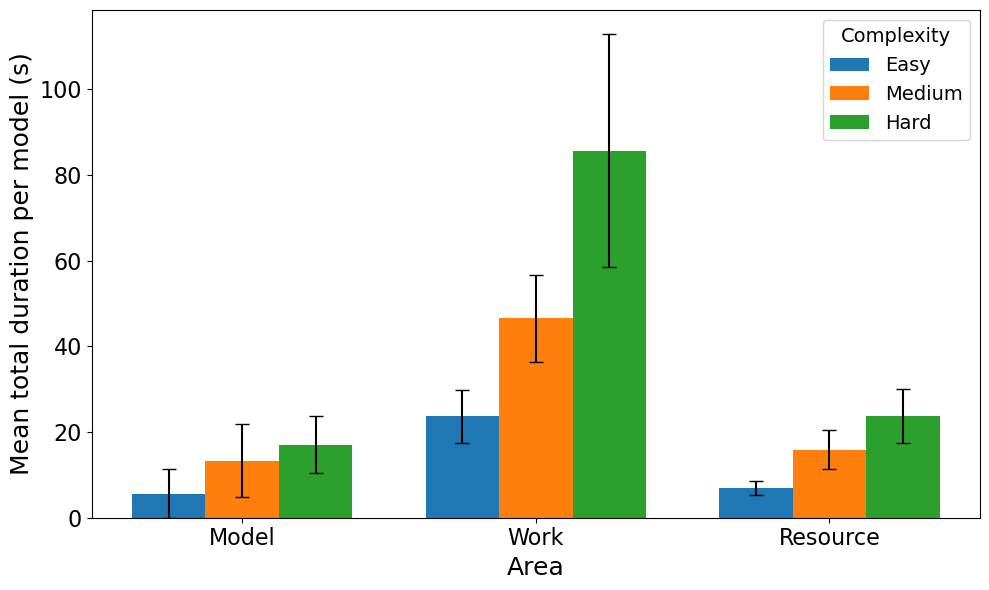


Summary of mean and standard deviation of durations:
  Complexity      Area  Mean_Duration  Std_Duration
0       Easy     Model       5.641946      5.615480
1       Easy      Work      23.643267      6.193942
2       Easy  Resource       6.932383      1.563588
3     Medium     Model      13.304450      8.553452
4     Medium      Work      46.581183     10.142325
5     Medium  Resource      15.852717      4.578733
6       Hard     Model      17.071950      6.745374
7       Hard      Work      85.623580     27.196860
8       Hard  Resource      23.735397      6.212343


In [ ]:
#----------------------------------------------------
# This is for Duration and complexity
#----------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# LOAD AGGREGATED DATA
# ---------------------------
df = area_model_df

areas = ["Model", "Work", "Resource"]
complexities = ["Easy", "Medium", "Hard"]

# ---------------------------
# AGGREGATE TO PARTICIPANT LEVEL
# ---------------------------
mean_durations = []
std_durations = []

for comp in complexities:
    df_comp = df[df["complexity"] == comp]

    comp_means = []
    comp_stds = []

    for area in areas:
        df_area = df_comp[df_comp["area"] == area]

        # total duration per model for each participant
        duration_per_participant = (
            df_area
            .groupby("participant")["total_duration"]
            .mean()  # average across models for each participant
            .dropna()
        )

        comp_means.append(duration_per_participant.mean())
        comp_stds.append(duration_per_participant.std())

    mean_durations.append(comp_means)
    std_durations.append(comp_stds)

mean_durations = np.array(mean_durations)
std_durations = np.array(std_durations)

# ---------------------------
# PLOT
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(areas))
width = 0.25  # 3 complexities → narrower bars

for i, comp in enumerate(complexities):
    ax.bar(
        x + i * width,
        mean_durations[i],
        width,
        yerr=std_durations[i],
        capsize=5,
        label=comp
    )

# ---------------------------
# LABELS & STYLE
# ---------------------------
ax.set_ylabel("Mean total duration per model (s)", fontsize=18)
ax.set_xlabel("Area", fontsize=18)

ax.set_xticks(x + width)
ax.set_xticklabels(areas, fontsize=16)

ax.tick_params(axis="y", labelsize=16)

ax.legend(
    title="Complexity",
    fontsize=14,
    title_fontsize=14
)

plt.tight_layout()
plt.show()

# ---------------------------
# SUMMARY DATAFRAME
# ---------------------------
summary_df = pd.DataFrame(
    {
        "Complexity": np.repeat(complexities, len(areas)),
        "Area": areas * len(complexities),
        "Mean_Duration": mean_durations.flatten(),
        "Std_Duration": std_durations.flatten()
    }
)

print("\nSummary of mean and standard deviation of durations:")
print(summary_df)


## **Shapiro and LMM for the dataset**

In [358]:
from scipy.stats import shapiro

# Load data
df = area_model_df

df["duration"] = np.log(df["total_duration"] + 1)
w, p = shapiro(df["duration"])
print("Shapiro Duration: W =", w, ", p =", p)

# Shapiro test for visit counts
df["visit"] = np.sqrt(df["n_visits"])
w, p = shapiro(df["visit"])
print("Shapiro Visits: W =", w, ", p =", p)


import matplotlib.pyplot as plt
import scipy.stats as stats

area_model_df["visits_"] = np.sqrt(area_model_df["n_visits"])

area_model_df["total_duration_"] = np.log(area_model_df["total_duration"] + 1e-6)

## LMM with interactions
model_duration = smf.mixedlm(
    "total_duration ~ condition + complexity + familiarity + area",
    data=area_model_df,
    groups=area_model_df["participant"]
).fit(method='nm')

print(model_duration.summary())

model_visit = smf.mixedlm(
     "n_visits ~ condition + complexity + familiarity + area",
     data=area_model_df,
     groups=area_model_df["participant"]
 ).fit(method='nm')

print(model_visit.summary())


formula_reduced = """
total_duration ~ 
    condition * complexity +
    condition * area +
    complexity * familiarity +
    complexity * area
"""

model_reduced = smf.mixedlm(
    formula_reduced,
    data=area_model_df,
    groups=area_model_df["participant"],   # random intercept
)
result_reduced = model_reduced.fit(method='nm')

print(result_reduced.summary())

formula_reduced = """
n_visits ~ 
    condition * complexity +
    condition * area +
    complexity * familiarity +
    complexity * area
"""

model_reduced = smf.mixedlm(
    formula_reduced,
    data=area_model_df,
    groups=area_model_df["participant"],   # random intercept
)
result_reduced = model_reduced.fit(method='nm')

print(result_reduced.summary())

Shapiro Duration: W = 0.9949931436557367 , p = 0.15491826689663915
Shapiro Visits: W = 0.9626566466886184 , p = 2.903639226092241e-09
              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   total_duration
No. Observations:   449       Method:               REML          
No. Groups:         10        Scale:                280.2864      
Min. group size:    34        Log-Likelihood:       -1895.4849    
Max. group size:    54        Converged:            Yes           
Mean group size:    44.9                                          
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               -3.637    3.113 -1.169 0.243 -9.738  2.463
condition[T.2_Delay]     0.965    1.950  0.495 0.621 -2.857  4.788
condition[T.Constant]    0.690    1.925  0.358 0.720 -3.083  4.462
complexity

# **Questionaire Analysis**

In [19]:
import pandas as pd

# Path to your CSV file
path = '/Users/lisa/Desktop/8. Semester/Data/results-survey922256-3.csv'

# Load data with tab separator
df = pd.read_csv(path, sep=',', encoding='utf-8')

# Clean column names (remove spaces, invisible characters)
df.columns = df.columns.str.strip()

# Select all question columns
question_cols = [col for col in df.columns if col.startswith(('IPQ'))]
#question_cols = ["IPQ01[SQ001]", "IPQ02[SQ001]", "IPQ05[SQ001]", "IPQ06[SQ001]"]


# Convert values to numeric (ignore any text)
df[question_cols] = df[question_cols].apply(pd.to_numeric, errors='coerce')

# Compute mean and standard deviation per question
stats = df[question_cols].agg(['mean', 'std']).T
stats.columns = ['Mean', 'Standard Deviation']

# Round for readability
stats = stats.round(2)

# Display results
print(stats)
# Optionally save to CSV
stats.to_csv('/Users/lisa/Desktop/8. Semester/Data/question_stats.csv')



              Mean  Standard Deviation
IPQ01[SQ001]   2.2                0.63
IPQ02[SQ001]   2.2                0.63
IPQ03[SQ001]  -1.7                1.49
IPQ04[SQ001]  -0.4                2.22
IPQ05[SQ001]   1.9                1.10
IPQ06[SQ001]   2.2                0.63
IPQ07[SQ001]  -0.1                1.52
IPQ08[SQ001]  -0.2                1.48
IPQ09[SQ001]   0.6                1.71
IPQ10[SQ001]   0.2                1.32
IPQ11[SQ001]  -0.4                1.58
IPQ12[SQ001]   0.1                1.10
IPQ13[SQ001]  -0.5                1.08
IPQ14[SQ001]  -1.8                1.69


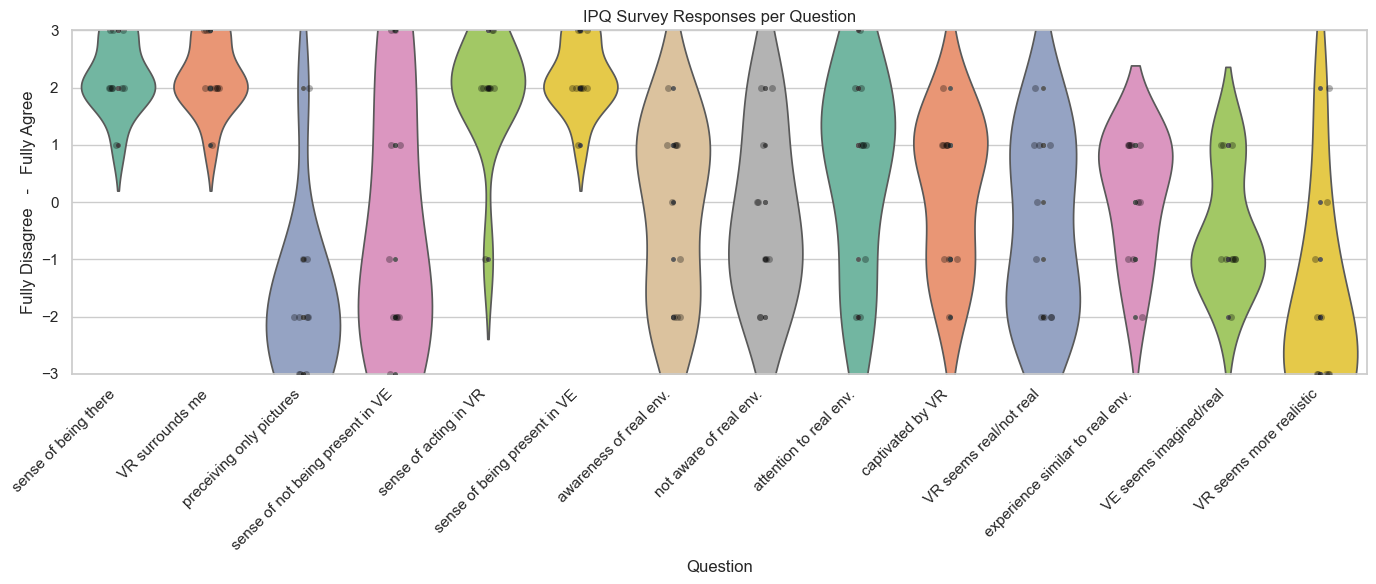

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape to long format
df_long = df[question_cols].melt(var_name='Question', value_name='Response')

label_map = {
    "IPQ01[SQ001]": "sense of being there",
    "IPQ02[SQ001]": "VR surrounds me",
    "IPQ03[SQ001]": "preceiving only pictures",
    "IPQ04[SQ001]": "sense of not being present in VE",
    "IPQ05[SQ001]": "sense of acting in VR",
    "IPQ06[SQ001]": "sense of being present in VE",
    "IPQ07[SQ001]": "awareness of real env.",
    "IPQ08[SQ001]": "not aware of real env.",
    "IPQ09[SQ001]": "attention to real env.",
    "IPQ10[SQ001]": "captivated by VR",
    "IPQ11[SQ001]": "VR seems real/not real",
    "IPQ12[SQ001]": "experience similar to real env.",
    "IPQ13[SQ001]": "VE seems imagined/real",
    "IPQ14[SQ001]": "VR seems more realistic"

}
df_long['Question'] = df_long['Question'].map(label_map)

# Set style
sns.set(style="whitegrid")

# Create plot
plt.figure(figsize=(14, 6))
sns.violinplot(data=df_long, x='Question', y='Response', hue='Question',
               inner='point', palette='Set2', legend=False)

sns.stripplot(data=df_long, x='Question', y='Response', color='black', alpha=0.3, jitter=True)

# Customize axes
plt.ylim(-3, 3)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fully Disagree   -   Fully Agree')
plt.title('IPQ Survey Responses per Question')
plt.tight_layout()
plt.show()